# 1. Data Exploration (10p)

### a. Explore the dataset by displaying the first few rows, summary statistics, and data types of each column.

In [75]:
import pandas as pd
import numpy as np
from pathlib import Path

# Locate the path to the dataset
data_path = Path("..") / "data" / "retail-sales-time-series" / "drsi.csv"

# Load with all columns treated as strings initially
df_raw = pd.read_csv(data_path, low_memory=False)

df_raw.head()


,Title,Implied deflator:AGG 1:Pred food stores - month on previous month%,Implied deflator:AGG 12:Pred non-food stores - month on previous month%,Implied deflator:47.19:Non-specialised stores - month on previous month%,"Implied deflator:AGG 5:Textile, clothing & footwear - month on previous month%",Implied deflator:AGG 7:Household goods stores - month on previous month%,Implied deflator:AGG 13:Other stores - month on previous month%,Implied deflator:AGG 1:Predominantly food stores - year on year%,Implied deflator:AGG 12:Predominantly non-food stores total - year on year%,Implied deflator:47.19:Non-specialised stores - year on year%,...,AGG 21: Implied Deflator Index: All retailing including automotive fuel,AGG 21X: Implied Deflator Index: All retailing excluding automotive fuel,AGG 1: Implied Deflator Index: Predominantly food stores,AGG 12: Implied Deflator Index:Total Predominantly non-food stores,47.19: Implied Deflator Index: Non-specialised stores,"AGG 5: Implied Deflator Index: Textile, clothing and footwear stores",AGG 7: Implied Deflator Index: Household goods stores,AGG 13: Implied Deflator Index: Other stores,AGG 14: Implied Deflator Index: Non store retailing,47.30: Implied Deflator Index: Predominantly automotive fuel
0,CDID,A4RT,A4RU,A4RV,A4RW,A4RX,A4RY,A4VJ,A4VK,A4VL,...,N3DK,N3DL,N3DM,N3DN,N3DO,N3DP,N3DQ,N3DR,N3DS,N3DT
1,PreUnit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Unit,%,%,%,%,%,%,%,%,%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Release Date,18-08-2023,18-08-2023,18-08-2023,18-08-2023,18-08-2023,18-08-2023,18-08-2023,18-08-2023,18-08-2023,...,18-08-2023,18-08-2023,18-08-2023,18-08-2023,18-08-2023,18-08-2023,18-08-2023,18-08-2023,18-08-2023,18-08-2023
4,Next release,22 September 2023,22 September 2023,22 September 2023,22 September 2023,22 September 2023,22 September 2023,22 September 2023,22 September 2023,22 September 2023,...,22 September 2023,22 September 2023,22 September 2023,22 September 2023,22 September 2023,22 September 2023,22 September 2023,22 September 2023,22 September 2023,22 September 2023


In [76]:
df_raw.describe()

,Title,Implied deflator:AGG 1:Pred food stores - month on previous month%,Implied deflator:AGG 12:Pred non-food stores - month on previous month%,Implied deflator:47.19:Non-specialised stores - month on previous month%,"Implied deflator:AGG 5:Textile, clothing & footwear - month on previous month%",Implied deflator:AGG 7:Household goods stores - month on previous month%,Implied deflator:AGG 13:Other stores - month on previous month%,Implied deflator:AGG 1:Predominantly food stores - year on year%,Implied deflator:AGG 12:Predominantly non-food stores total - year on year%,Implied deflator:47.19:Non-specialised stores - year on year%,...,AGG 21: Implied Deflator Index: All retailing including automotive fuel,AGG 21X: Implied Deflator Index: All retailing excluding automotive fuel,AGG 1: Implied Deflator Index: Predominantly food stores,AGG 12: Implied Deflator Index:Total Predominantly non-food stores,47.19: Implied Deflator Index: Non-specialised stores,"AGG 5: Implied Deflator Index: Textile, clothing and footwear stores",AGG 7: Implied Deflator Index: Household goods stores,AGG 13: Implied Deflator Index: Other stores,AGG 14: Implied Deflator Index: Non store retailing,47.30: Implied Deflator Index: Predominantly automotive fuel
count,610,430,430,430,430,430,430,419,419,419,...,430,430,430,430,430,430,430,430,430,346
unique,610,33,54,49,92,60,41,126,100,99,...,234,206,256,184,174,224,221,174,190,267
top,CDID,0.2,0.2,0.6,0.6,0.4,0.4,1.6,-1.5,0.1,...,81.5,82.8,69.8,98.6,100.0,99.0,99.0,100.3,99.4,59.6
freq,1,40,23,29,23,25,40,12,16,14,...,9,8,7,9,10,7,6,10,7,4


By inspecting the count row, several columns have a count lower than the total number of rows. This indicates that the data contains missing values. Most columns have 430 non-missing values, meaning that 180 values are missing (610 − 430 = 180). Some columns have even more missing values, with counts of 419 and 346.

In addition, the first column has no missing values, as its count is 610. It also has 610 unique values, with the most frequent value occurring only once (freq = 1). This suggests that the first column may contain unique identifiers, dates, or other metadata rather than a variable with repeated observations.

In [77]:
df_raw.dtypes

Title                                                                             str
Implied deflator:AGG 1:Pred food stores - month on previous month%                str
Implied deflator:AGG 12:Pred non-food stores - month on previous month%           str
Implied deflator:47.19:Non-specialised stores - month on previous month%          str
Implied deflator:AGG 5:Textile, clothing & footwear - month on previous month%    str
                                                                                 ... 
AGG 5: Implied Deflator Index: Textile, clothing and footwear stores              str
AGG 7: Implied Deflator Index: Household goods stores                             str
AGG 13: Implied Deflator Index: Other stores                                      str
AGG 14: Implied Deflator Index: Non store retailing                               str
47.30: Implied Deflator Index: Predominantly automotive fuel                      str
Length: 622, dtype: object

All the data is stored as strings. This explains why the min, max and mean did not appear in the describe() call. It is therefore important to handle conversion from str -> desired type before displaying the data.

### b. Identify missing values, outliers, and unique values in categorical columns.

In [78]:
# Identify metadata rows
metadata_keywords = ['CDID', 'PreUnit', 'Unit', 'Release Date', 
                      'Next release', 'Important Notes', 'Notes']

# Find where actual data begins
data_start = 0
for i, val in enumerate(df_raw['Title']):
    if val not in metadata_keywords and pd.notna(val):
        data_start = i
        break

# Split
metadata = df_raw.iloc[:data_start].copy()
data = df_raw.iloc[data_start:].copy().reset_index(drop=True)

print(f"Metadata rows: {len(metadata)}")
print(f"Data rows: {len(data)}")
print(f"First data entry: {data['Title'].iloc[0]}")


Metadata rows: 6
Data rows: 604
First data entry: 1988


In [79]:
def parse_rsi_date(date_str):
    """Parse ONS RSI date formats: YYYY MON, YYYY QN, YYYY"""
    date_str = str(date_str).strip()
    
    # Monthly format: "1997 MAY"
    if ' ' in date_str and 'Q' not in date_str:
        return pd.to_datetime(date_str, format='%Y %b', errors='coerce')
    
    # Quarterly format: "2020 Q2"
    elif 'Q' in date_str:
        year, q = date_str.split(' Q')
        month = (int(q) - 1) * 3 + 1  # Q1=Jan, Q2=Apr, Q3=Jul, Q4=Oct
        return pd.to_datetime(f"{year}-{month:02d}-01", errors='coerce')
    
    # Annual format: "2021"
    elif date_str.isdigit():
        return pd.to_datetime(f"{date_str}-01-01", errors='coerce')
    
    return pd.NaT

# Apply parsing
data['Date'] = data['Title'].apply(parse_rsi_date)

# Tag the temporal frequency
data['Frequency'] = data['Title'].apply(
    lambda x: 'Quarterly' if 'Q' in str(x) 
    else ('Annual' if str(x).strip().isdigit() else 'Monthly')
)

print("Date parsing results:")
print(data['Frequency'].value_counts())
print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")
print(f"Unparsed: {data['Date'].isna().sum()}")


Date parsing results:
Frequency
Monthly      427
Quarterly    142
Annual        35
Name: count, dtype: int64
Date range: 1988-01-01 00:00:00 to 2023-07-01 00:00:00
Unparsed: 0


In [80]:
# Convert all value columns (everything except the helper columns) to numeric.
# ONS values are stored as strings; blanks/markers ('.', '..') become NaN via errors='coerce'.
value_cols = data.columns.drop(['Title', 'Date', 'Frequency'])
data[value_cols] = data[value_cols].apply(pd.to_numeric, errors='coerce')

# Verify
print(data[value_cols].dtypes.value_counts())
print(f"Total NaNs after conversion: {data[value_cols].isna().sum().sum()}")

float64    621
Name: count, dtype: int64
Total NaNs after conversion: 73935


In [81]:
# Split into separate DataFrames
monthly_data = data[data['Frequency'] == 'Monthly'].copy()
quarterly_data = data[data['Frequency'] == 'Quarterly'].copy()
annual_data = data[data['Frequency'] == 'Annual'].copy()

print(f"Monthly rows:  {len(monthly_data)}")
print(f"Quarterly rows: {len(quarterly_data)}")
print(f"Annual rows:   {len(annual_data)}")


Monthly rows:  427
Quarterly rows: 142
Annual rows:   35


In [ ]:
ranges = []

for col in data.columns:
    if col in ['Title', 'Date', 'Frequency']:
        continue

    valid = data[data[col].notna()]

    if len(valid) > 0:
        first = valid['Date'].min()
        last = valid['Date'].max()

        ranges.append({
            'Variable': col,
            'First': first,
            'Last': last,
            'Days': (last - first).days
        })

ranges = pd.DataFrame(ranges)

shortest = ranges.sort_values('Days').iloc[0]

print(shortest)


Variable    RSI:Internet:Household goods stores:All Bus:VA...
First                                     2010-01-01 00:00:00
Last                                      2023-07-01 00:00:00
Days                                                     4929
Name: 548, dtype: object


,Variable,First,Last,Days
0,Implied deflator:AGG 1:Pred food stores - mont...,1988-02-01,2023-07-01,12934
1,Implied deflator:AGG 12:Pred non-food stores -...,1988-02-01,2023-07-01,12934
2,Implied deflator:47.19:Non-specialised stores ...,1988-02-01,2023-07-01,12934
3,"Implied deflator:AGG 5:Textile, clothing & foo...",1988-02-01,2023-07-01,12934
4,Implied deflator:AGG 7:Household goods stores ...,1988-02-01,2023-07-01,12934


In [131]:
print(shortest['Variable'])

RSI:Internet:Household goods stores:All Bus:VAL NSA:%change month a year ago


In [122]:
# Check missing data patterns
missing = data.isna().sum()

print(missing[missing > 0])


Implied deflator:AGG 1:Pred food stores - month on previous month%                178
Implied deflator:AGG 12:Pred non-food stores - month on previous month%           178
Implied deflator:47.19:Non-specialised stores - month on previous month%          178
Implied deflator:AGG 5:Textile, clothing & footwear - month on previous month%    178
Implied deflator:AGG 7:Household goods stores - month on previous month%          178
                                                                                 ... 
AGG 5: Implied Deflator Index: Textile, clothing and footwear stores              177
AGG 7: Implied Deflator Index: Household goods stores                             177
AGG 13: Implied Deflator Index: Other stores                                      177
AGG 14: Implied Deflator Index: Non store retailing                               177
47.30: Implied Deflator Index: Predominantly automotive fuel                      261
Length: 469, dtype: int64


In [125]:
row_missing = data.isna().sum(axis=1)

worst_row = row_missing.idxmax()

print(data.loc[worst_row, ['Date', 'Frequency']])
print("Missing:", row_missing.loc[worst_row])
print("Present:", data.loc[worst_row].notna().sum())

Date         1988-01-01 00:00:00
Frequency                 Annual
Name: 1970-01-01 00:00:00, dtype: object
Missing: 469
Present: 155


In [ ]:
for col in value_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Implied deflator:AGG 1:Pred food stores - month on previous month%: 8 outliers
Implied deflator:AGG 12:Pred non-food stores - month on previous month%: 28 outliers
Implied deflator:47.19:Non-specialised stores - month on previous month%: 10 outliers
Implied deflator:AGG 5:Textile, clothing & footwear - month on previous month%: 48 outliers
Implied deflator:AGG 7:Household goods stores - month on previous month%: 13 outliers
Implied deflator:AGG 13:Other stores - month on previous month%: 5 outliers
Implied deflator:AGG 1:Predominantly food stores - year on year%: 24 outliers
Implied deflator:AGG 12:Predominantly non-food stores total - year on year%: 11 outliers
Implied deflator:47.19:Non-specialised stores - year on year%: 24 outliers
Implied deflator:AGG 5:Textile, clothing & footwearstores - year on year%: 21 outliers
Implied deflator:AGG 7:Household goods stores - year on year%: 28 outliers
Implied deflator:AGG 13:Other stores - year on year%: 0 outliers
RSI: Specialist Food Stores

In [168]:
import re

def get_base_name(col):
    col = str(col)

    # Remove SA/NSA regardless of capitalization
    col = re.sub(r'\bNSA\b', '', col, flags=re.IGNORECASE)
    col = re.sub(r'\bSA\b', '', col, flags=re.IGNORECASE)

    return ' '.join(col.split())


sa_cols = [
    col for col in df.columns
    if re.search(r'\bSA\b', str(col), re.IGNORECASE)
    and not re.search(r'\bNSA\b', str(col), re.IGNORECASE)
]

nsa_cols = [
    col for col in df.columns
    if re.search(r'\bNSA\b', str(col), re.IGNORECASE)
]


sa_base = {get_base_name(col): col for col in sa_cols}
nsa_base = {get_base_name(col): col for col in nsa_cols}

common_pairs = set(sa_base) & set(nsa_base)

print("SA columns:", len(sa_cols))
print("NSA columns:", len(nsa_cols))
print("Matching pairs:", len(common))

SA columns: 221
NSA columns: 238
Matching pairs: 98


In [158]:
pairs = []

for base in sorted(common):
    pairs.append({
        "base": base,
        "SA": sa_base[base],
        "NSA": nsa_base[base]
    })

pairs_df = pd.DataFrame(pairs)

print(pairs_df.to_string(index=False))

                                                                         base                                                                              SA                                                                              NSA
             RSI: Alcoholic Drinks, Beverages & Tobacco (val ) All Business %              RSI: Alcoholic Drinks, Beverages & Tobacco (val sa) All Business %              RSI: Alcoholic Drinks, Beverages & Tobacco (val nsa) All Business %
         RSI: Alcoholic Drinks, Beverages & Tobacco (val ) All Business Index          RSI: Alcoholic Drinks, Beverages & Tobacco (val sa) All Business Index          RSI: Alcoholic Drinks, Beverages & Tobacco (val nsa) All Business Index
             RSI: Alcoholic Drinks, Beverages & Tobacco (vol ) All Business %              RSI: Alcoholic Drinks, Beverages & Tobacco (vol sa) All Business %              RSI: Alcoholic Drinks, Beverages & Tobacco (vol nsa) All Business %
         RSI: Alcoholic Drinks, Beverages & 

In [169]:
residuals = {}
for base in common_pairs:
    sa_col, nsa_col = sa_base[base], nsa_base[base]
    # Force numeric conversion (non‑numeric entries become NaN)
    sa  = pd.to_numeric(df[sa_col],  errors='coerce')
    nsa = pd.to_numeric(df[nsa_col], errors='coerce')
    residuals[base] = nsa - sa


In [170]:
def iqr_flags(series):
    """Return a Boolean Series: True where the value is an IQR outlier."""
    q1, q3 = np.percentile(series.dropna(), [25, 75])
    iqr   = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (series < lower) | (series > upper)

def zscore_flags(series):
    """Return a Boolean Series: True where the absolute Z‑score > 3."""
    z = np.abs(stats.zscore(series.dropna()))
    # Align the boolean mask with the original index
    mask = pd.Series(False, index=series.index)
    mask[series.dropna().index] = z > 3
    return mask


In [176]:
import pandas as pd
import re
import numpy as np
from scipy import stats          # ←  this line was missing


outlier_summary = {}

for base in common_pairs:
    sa_col, nsa_col = sa_base[base], nsa_base[base]
    res_series      = residuals[base].astype(float)

    # ----- flags for SA -----
    sa_iqr  = iqr_flags(pd.to_numeric(df[sa_col], errors='coerce'))
    sa_z    = zscore_flags(pd.to_numeric(df[sa_col], errors='coerce'))

    # ----- flags for NSA -----
    nsa_iqr = iqr_flags(pd.to_numeric(df[nsa_col], errors='coerce'))
    nsa_z   = zscore_flags(pd.to_numeric(df[nsa_col], errors='coerce'))

    # ----- flags for residual -----
    res_iqr = iqr_flags(res_series)
    res_z   = zscore_flags(res_series)

    # combine; a row is “outlier” for this pair if *any* flag is True
    combined = sa_iqr | sa_z | nsa_iqr | nsa_z | res_iqr | res_z

    outlier_summary[base] = combined[combined].index.tolist()


InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [162]:
series["rolling_median"] = (
    series[sa_col]
    .rolling(window=12, center=True)
    .median()
)

series["residual"] = (
    series[sa_col] - series["rolling_median"]
)

In [163]:
q1 = series["residual"].quantile(0.25)
q3 = series["residual"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

series["outlier"] = (
    (series["residual"] < lower) |
    (series["residual"] > upper)
)

outliers = series[series["outlier"]]

print(outliers[["Date", sa_col, "residual", "outlier"]])

                                    Date  \
1970-01-01 00:00:00.000000022 2010-01-01   
1970-01-01 00:00:00.000000024 2012-01-01   
1970-01-01 00:00:00.000000027 2015-01-01   
1970-01-01 00:00:00.000000028 2016-01-01   
1970-01-01 00:00:00.000000029 2017-01-01   
...                                  ...   
1970-01-01 00:00:00.000000583 2021-11-01   
1970-01-01 00:00:00.000000584 2021-12-01   
1970-01-01 00:00:00.000000585 2022-01-01   
1970-01-01 00:00:00.000000586 2022-02-01   
1970-01-01 00:00:00.000000591 2022-07-01   

                               RSI: Alcoholic Drinks, Beverages & Tobacco (val sa) All Business %  \
1970-01-01 00:00:00.000000022                                              -21.2                    
1970-01-01 00:00:00.000000024                                              -14.4                    
1970-01-01 00:00:00.000000027                                               11.9                    
1970-01-01 00:00:00.000000028                                      

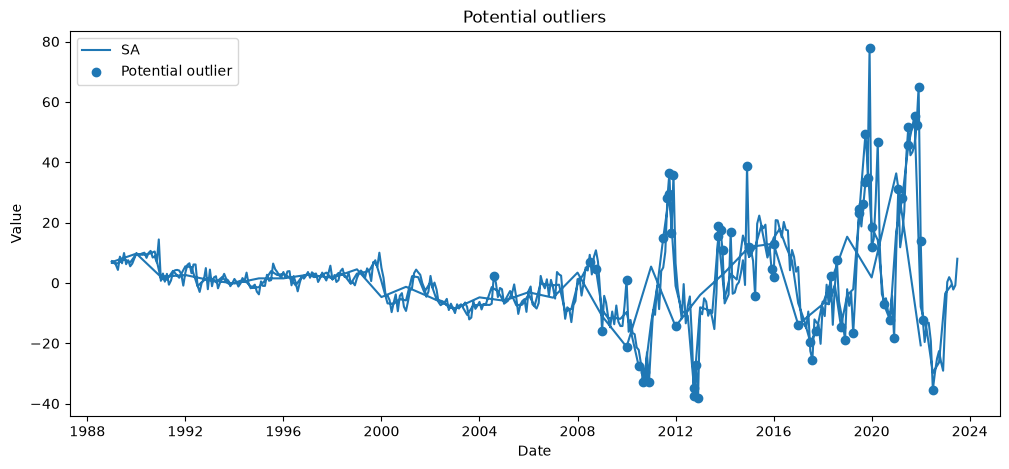

In [164]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(series["Date"], series[sa_col], label="SA")

plt.scatter(
    series.loc[series["outlier"], "Date"],
    series.loc[series["outlier"], sa_col],
    label="Potential outlier"
)

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Potential outliers")
plt.legend()
plt.show()

In [165]:
print(series[[sa_col, "residual"]].describe())

       RSI: Alcoholic Drinks, Beverages & Tobacco (val sa) All Business %  \
count                                         587.000000                    
mean                                            0.099319                    
std                                            13.267712                    
min                                           -38.300000                    
25%                                            -7.100000                    
50%                                            -0.100000                    
75%                                             4.350000                    
max                                            77.700000                    

         residual  
count  554.000000  
mean     0.534386  
std      8.238533  
min    -30.000000  
25%     -2.237500  
50%      0.000000  
75%      2.287500  
max     60.600000  


In [166]:
q1 = series[sa_col].quantile(0.25)
q3 = series[sa_col].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

series["outlier"] = (
    (series[sa_col] < lower) |
    (series[sa_col] > upper)
)

print(
    series.loc[
        series["outlier"],
        ["Date", sa_col, nsa_col]
    ]
)

                                    Date  \
1970-01-01 00:00:00.000000033 2021-01-01   
1970-01-01 00:00:00.000000125 2010-07-01   
1970-01-01 00:00:00.000000126 2010-10-01   
1970-01-01 00:00:00.000000130 2011-10-01   
1970-01-01 00:00:00.000000134 2012-10-01   
1970-01-01 00:00:00.000000161 2019-07-01   
1970-01-01 00:00:00.000000162 2019-10-01   
1970-01-01 00:00:00.000000168 2021-04-01   
1970-01-01 00:00:00.000000169 2021-07-01   
1970-01-01 00:00:00.000000170 2021-10-01   
1970-01-01 00:00:00.000000173 2022-07-01   
1970-01-01 00:00:00.000000174 2022-10-01   
1970-01-01 00:00:00.000000448 2010-08-01   
1970-01-01 00:00:00.000000449 2010-09-01   
1970-01-01 00:00:00.000000450 2010-10-01   
1970-01-01 00:00:00.000000452 2010-12-01   
1970-01-01 00:00:00.000000461 2011-09-01   
1970-01-01 00:00:00.000000462 2011-10-01   
1970-01-01 00:00:00.000000464 2011-12-01   
1970-01-01 00:00:00.000000474 2012-10-01   
1970-01-01 00:00:00.000000475 2012-11-01   
1970-01-01 00:00:00.000000476 20

In [180]:
value_cols = [c for c in data.columns if c not in ['Title', 'Date', 'Frequency']]
for c in value_cols:
    data[c] = pd.to_numeric(data[c], errors='coerce')
data = data.sort_values('Date').reset_index(drop=True)

def col_type(c):
    cl = c.lower()
    if 'index' in cl:
        return 'level'          # trending -> test on period-on-period % change
    if '%' in c or 'percent' in cl or 'proportion' in cl:
        return 'percent'        # already a change/ratio -> test directly
    return 'level'

col_types = {c: col_type(c) for c in value_cols}

def already_deseasonalized(c):
    # year-on-year / YTD comparisons already cancel normal seasonality
    cl = c.lower()
    return any(k in cl for k in ['year ago', 'year earlier', 'year on year', 'yoy', 'year to date'])

def mad_zscore(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return np.zeros_like(x) if mad == 0 else 0.6745 * (x - med) / mad

MIN_OBS, Z_THRESH, IQR_MULT = 8, 3.5, 1.5
period_map = {'Monthly': data['Date'].dt.month, 'Quarterly': data['Date'].dt.quarter}

records = []
for c in value_cols:
    for freq, sub in data.groupby('Frequency'):
        s = sub[c]
        valid = s.notna()
        if valid.sum() < MIN_OBS:
            continue
        idx, raw = sub.index[valid], s[valid].values
        test_vals = raw.copy() if col_types[c] == 'percent' else pd.Series(raw).pct_change().values

        if freq in period_map and not already_deseasonalized(c):
            period = period_map[freq].loc[idx].values
            tmp = pd.Series(test_vals, index=idx)
            seasonal_avg = tmp.groupby(period).transform(lambda g: g.mean() if g.notna().sum() >= 3 else np.nan)
            test_vals = (tmp - seasonal_avg).values

        finite = np.isfinite(test_vals)
        if finite.sum() < MIN_OBS:
            continue
        tv, test_idx = test_vals[finite], idx[finite]
        q1, q3 = np.percentile(tv, [25, 75])
        iqr = q3 - q1
        iqr_flag = (tv < q1 - IQR_MULT * iqr) | (tv > q3 + IQR_MULT * iqr)
        z_flag = np.abs(mad_zscore(tv)) > Z_THRESH
        confirmed = iqr_flag & z_flag
        for i, date, flagged in zip(test_idx, sub.loc[test_idx, 'Date'], confirmed):
            if flagged:
                records.append({'column': c, 'type': col_types[c], 'frequency': freq,
                                 'row_index': i, 'date': date})

outlier_log = pd.DataFrame(records)
print(f"Confirmed outliers: {len(outlier_log)} ({100*len(outlier_log)/sum(data[c].notna().sum() for c in value_cols):.2f}% of valid data)")

data_capped = data.copy()
for col, grp in outlier_log.groupby('column'):
    for freq, g in grp.groupby('frequency'):
        block_idx = data.index[data['Frequency'] == freq]
        s = data_capped.loc[block_idx, col].copy()
        s.loc[g['row_index'].values] = np.nan
        data_capped.loc[block_idx, col] = s.interpolate(method='linear', limit_direction='both')

        

Confirmed outliers: 10951 (3.64% of valid data)


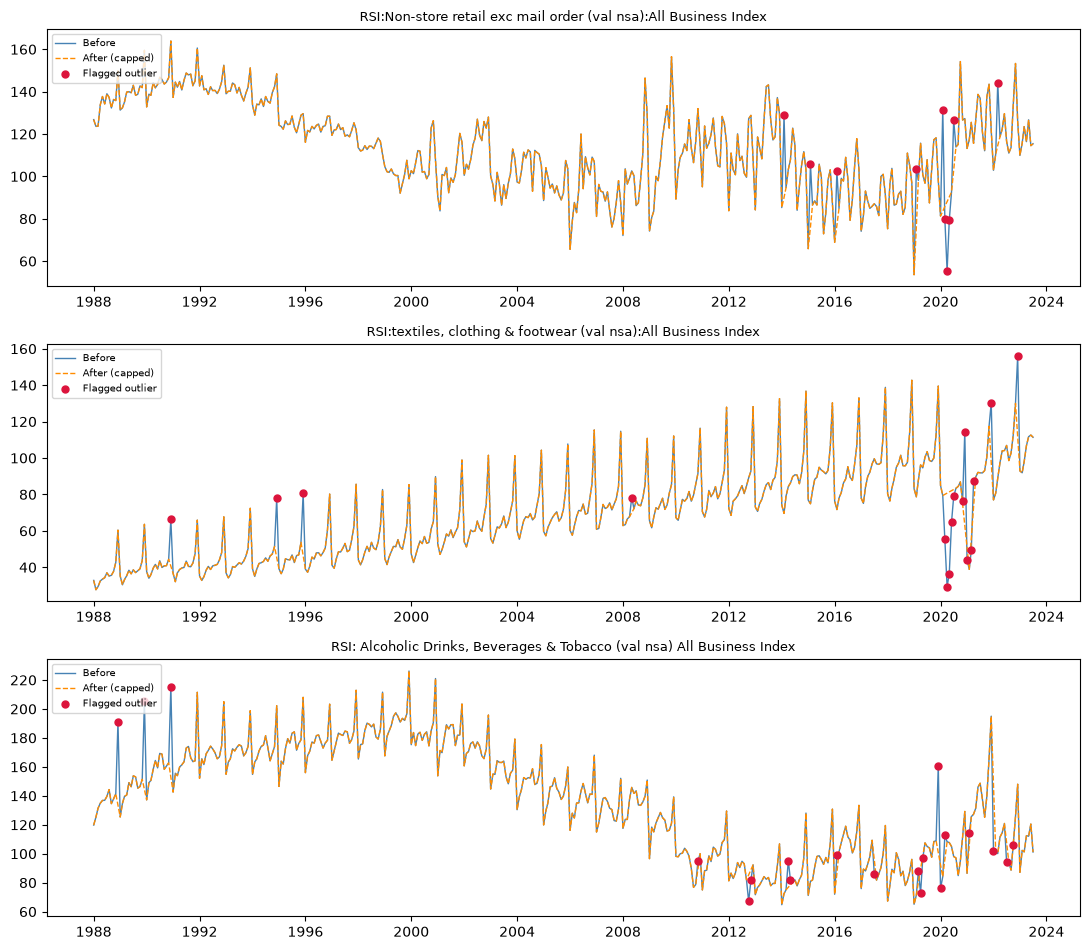

In [181]:
import matplotlib.pyplot as plt

example_cols = [
    'RSI:Non-store retail exc mail order (val nsa):All Business Index',        # COVID online-shopping surge
    'RSI:textiles, clothing & footwear (val nsa):All Business Index',          # COVID lockdown clothing crash
    'RSI: Alcoholic Drinks, Beverages & Tobacco (val nsa) All Business Index', # panic-buying spikes
]

fig, axes = plt.subplots(len(example_cols), 1, figsize=(11, 3.2 * len(example_cols)))
for ax, col in zip(axes, example_cols):
    mask = data['Frequency'] == 'Monthly'
    x = data.loc[mask, 'Date']
    out_dates = set(outlier_log.loc[(outlier_log['column'] == col) & (outlier_log['frequency'] == 'Monthly'), 'date'])
    is_out = x.isin(out_dates)

    ax.plot(x, data.loc[mask, col], color='steelblue', lw=1, label='Before')
    ax.plot(x, data_capped.loc[mask, col], color='darkorange', lw=1, ls='--', label='After (capped)')
    ax.scatter(x[is_out], data.loc[mask, col][is_out], color='crimson', s=25, zorder=5, label='Flagged outlier')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

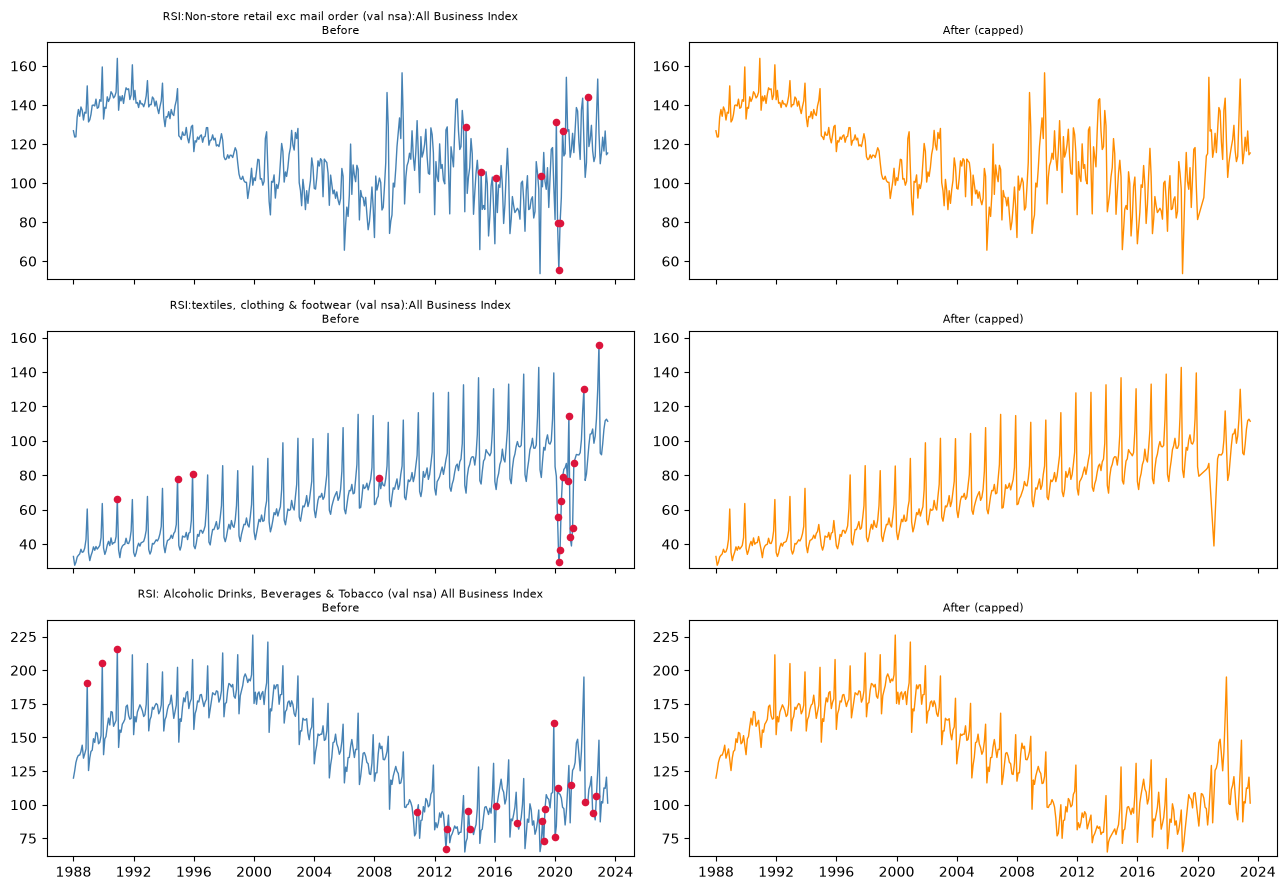

In [ ]:
example_cols = [
    'RSI:Non-store retail exc mail order (val nsa):All Business Index',        # COVID online-shopping surge
    'RSI:textiles, clothing & footwear (val nsa):All Business Index',          # COVID lockdown clothing crash
]

fig, axes = plt.subplots(len(example_cols), 2, figsize=(13, 3 * len(example_cols)), sharex='col')

for row, col in zip(axes, example_cols):
    mask = data['Frequency'] == 'Monthly'
    x = data.loc[mask, 'Date']
    out_dates = set(outlier_log.loc[(outlier_log['column'] == col) & (outlier_log['frequency'] == 'Monthly'), 'date'])
    is_out = x.isin(out_dates)

    ax_before, ax_after = row
    ax_before.plot(x, data.loc[mask, col], color='steelblue', lw=1)
    ax_before.scatter(x[is_out], data.loc[mask, col][is_out], color='crimson', s=20, zorder=5)
    ax_before.set_title(f'{col}\nBefore', fontsize=8)

    ax_after.plot(x, data_capped.loc[mask, col], color='darkorange', lw=1)
    ax_after.set_title('After (capped)', fontsize=8)

    # shared y-limits so the shape is directly comparable left vs right
    ylim = (min(data.loc[mask, col].min(), data_capped.loc[mask, col].min()) * 0.95,
            max(data.loc[mask, col].max(), data_capped.loc[mask, col].max()) * 1.05)
    ax_before.set_ylim(ylim)
    ax_after.set_ylim(ylim)

plt.tight_layout()
plt.show()

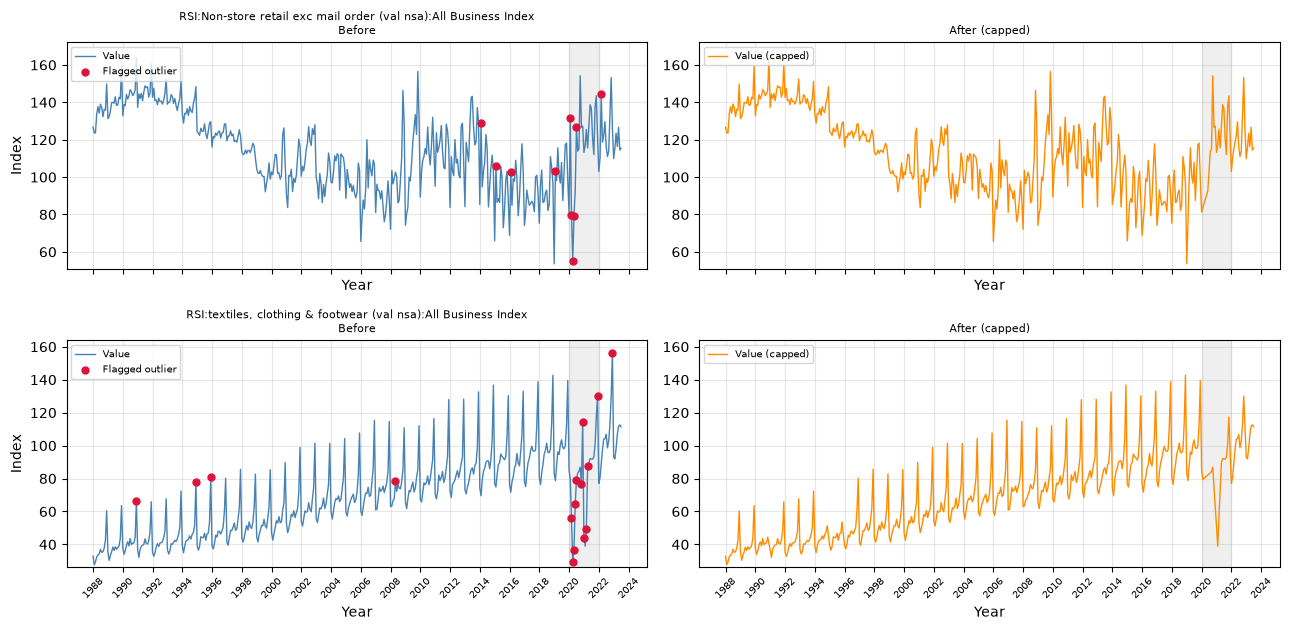

In [184]:
import matplotlib.dates as mdates

example_cols = [
    'RSI:Non-store retail exc mail order (val nsa):All Business Index',        # COVID online-shopping surge
    'RSI:textiles, clothing & footwear (val nsa):All Business Index',          # COVID lockdown clothing crash
]

fig, axes = plt.subplots(len(example_cols), 2, figsize=(13, 3.2 * len(example_cols)), sharex='col')

for row, col in zip(axes, example_cols):
    mask = data['Frequency'] == 'Monthly'
    x = data.loc[mask, 'Date']
    out_dates = set(outlier_log.loc[(outlier_log['column'] == col) & (outlier_log['frequency'] == 'Monthly'), 'date'])
    is_out = x.isin(out_dates)

    ax_before, ax_after = row
    ax_before.plot(x, data.loc[mask, col], color='steelblue', lw=1, label='Value')
    ax_before.scatter(x[is_out], data.loc[mask, col][is_out], color='crimson', s=25, zorder=5, label='Flagged outlier')
    ax_before.set_title(f'{col}\nBefore', fontsize=8)
    ax_before.set_ylabel('Index')
    ax_before.legend(fontsize=7, loc='upper left')

    ax_after.plot(x, data_capped.loc[mask, col], color='darkorange', lw=1, label='Value (capped)')
    ax_after.set_title('After (capped)', fontsize=8)
    ax_after.legend(fontsize=7, loc='upper left')

    ylim = (min(data.loc[mask, col].min(), data_capped.loc[mask, col].min()) * 0.95,
            max(data.loc[mask, col].max(), data_capped.loc[mask, col].max()) * 1.05)

    for ax in (ax_before, ax_after):
        ax.set_ylim(ylim)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(mdates.YearLocator(2))       # tick every 2 years
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), color='grey', alpha=0.12)  # highlight COVID period
    ax_before.set_xlabel('Year')
    ax_after.set_xlabel('Year')

plt.tight_layout()
plt.show()

In [183]:
col = 'RSI:Non-store retail exc mail order (val nsa):All Business Index'
mask = (data['Frequency'] == 'Monthly') & (data['Date'].between('2019-06-01', '2021-06-01'))
comparison = pd.DataFrame({
    'date': data.loc[mask, 'Date'],
    'before': data.loc[mask, col],
    'after': data_capped.loc[mask, col],
}).set_index('date')
comparison['flagged'] = comparison.index.isin(
    outlier_log.loc[outlier_log['column'] == col, 'date']
)
print(comparison)

            before   after  flagged
date                               
2019-06-01    96.8   96.80    False
2019-07-01   107.9  107.90    False
2019-08-01    87.5   87.50    False
2019-09-01   103.2  103.20    False
2019-10-01   117.3  117.30    False
2019-11-01   118.2  118.20    False
2019-12-01    98.3   98.30    False
2020-01-01    81.3   81.30    False
2020-02-01   131.5   83.56     True
2020-03-01    79.8   85.82     True
2020-04-01    55.3   88.08     True
2020-05-01    79.4   90.34     True
2020-06-01    92.6   92.60    False
2020-07-01   126.6  103.25     True
2020-08-01   113.9  113.90    False
2020-09-01   115.1  115.10    False
2020-10-01   154.2  154.20    False
2020-11-01   126.6  126.60    False
2020-12-01   127.3  127.30    False
2021-01-01   113.2  113.20    False
2021-02-01   117.3  117.30    False
2021-03-01   125.5  125.50    False
2021-04-01   115.6  115.60    False
2021-05-01   126.5  126.50    False
2021-06-01   138.7  138.70    False


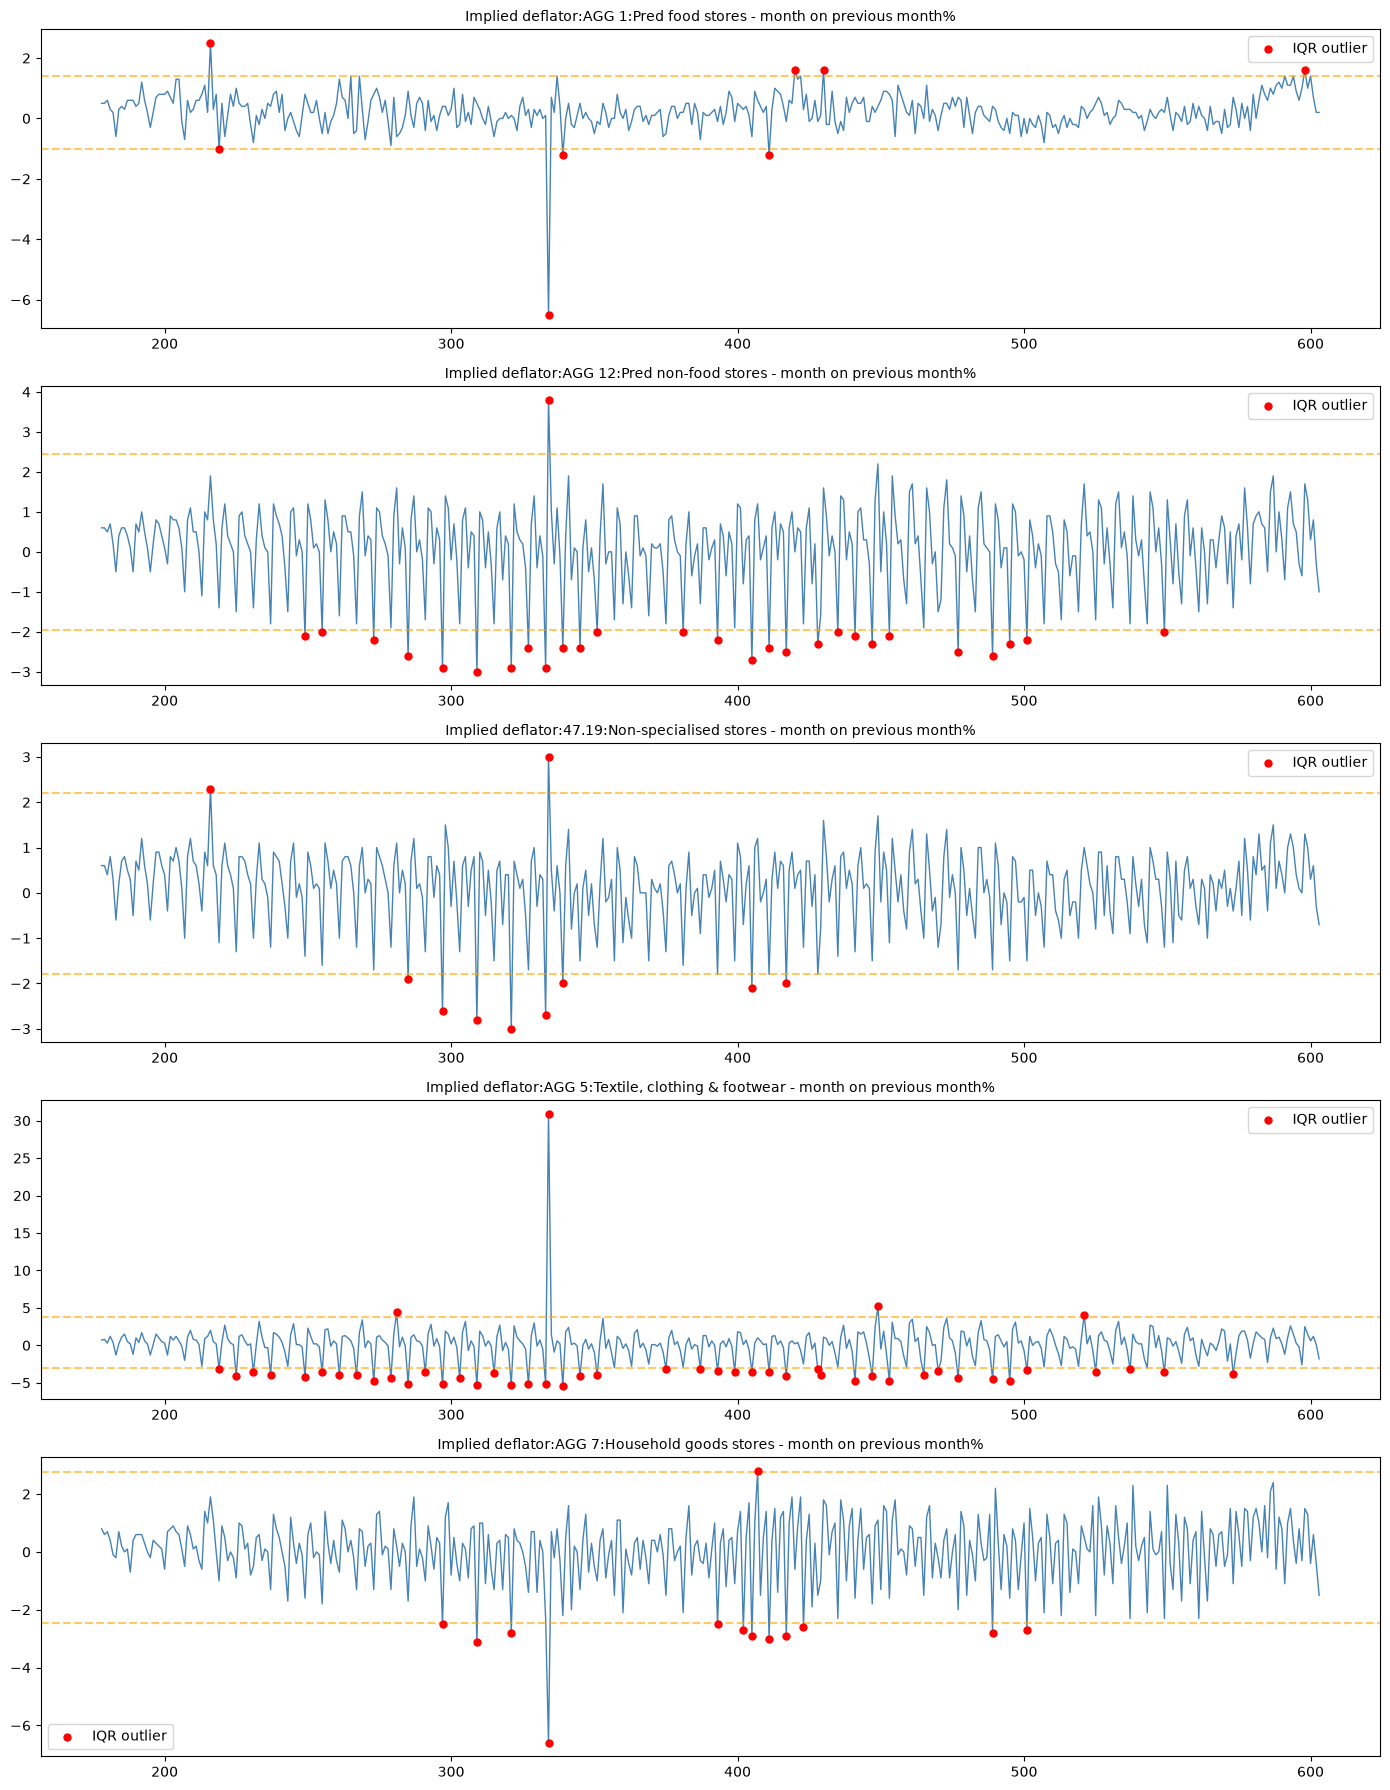

In [89]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for ax, col in zip(axes, value_cols[:5]):

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Plot the original series
    ax.plot(data.index, data[col], color="steelblue", linewidth=1)

    # Identify IQR outliers
    outliers = (data[col] < lower) | (data[col] > upper)

    # Highlight outliers
    ax.scatter(
        data.index[outliers],
        data.loc[outliers, col],
        color="red",
        s=25,
        label="IQR outlier",
        zorder=3
    )

    ax.set_title(col, fontsize=10)
    ax.axhline(lower, color="orange", linestyle="--", alpha=0.6)
    ax.axhline(upper, color="orange", linestyle="--", alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()


IQR on the global domain works well for detecting shocks in the data, but is strugeling to distinguage seasonal patterns compared to actual outliers. Therefore, we try to perform the IQR on the data stript from seasonality.

Implied deflator:AGG 1:Pred food stores - month on previous month%: 2 outliers
Implied deflator:AGG 12:Pred non-food stores - month on previous month%: 1 outliers
Implied deflator:47.19:Non-specialised stores - month on previous month%: 5 outliers
Implied deflator:AGG 5:Textile, clothing & footwear - month on previous month%: 1 outliers
Implied deflator:AGG 7:Household goods stores - month on previous month%: 1 outliers
Implied deflator:AGG 13:Other stores - month on previous month%: 3 outliers
Implied deflator:AGG 1:Predominantly food stores - year on year%: 10 outliers
Implied deflator:AGG 12:Predominantly non-food stores total - year on year%: 4 outliers
Implied deflator:47.19:Non-specialised stores - year on year%: 0 outliers
Implied deflator:AGG 5:Textile, clothing & footwearstores - year on year%: 12 outliers
Implied deflator:AGG 7:Household goods stores - year on year%: 13 outliers
Implied deflator:AGG 13:Other stores - year on year%: 0 outliers
RSI: Specialist Food Stores (val 

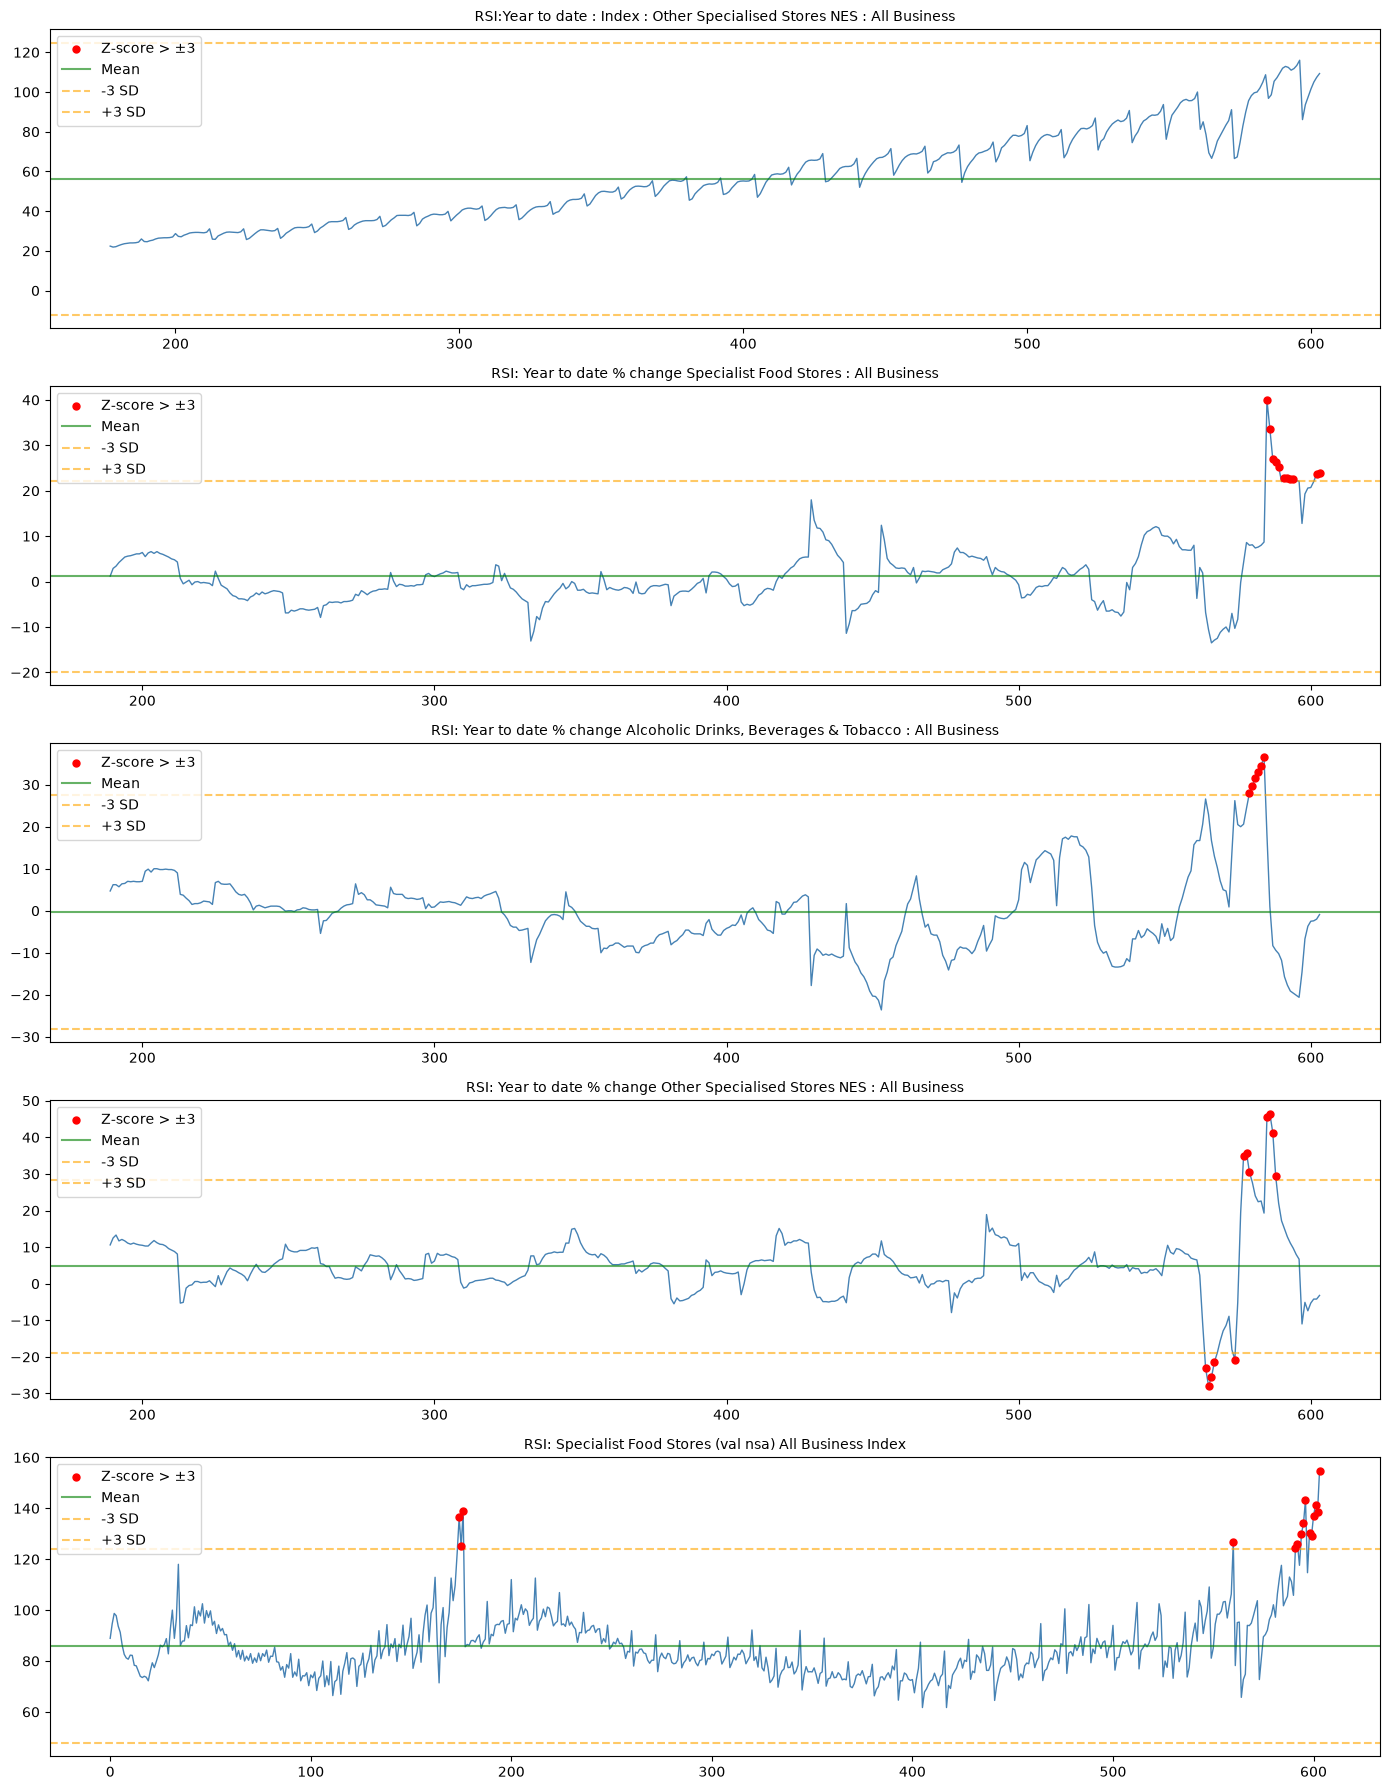

In [104]:
import matplotlib.pyplot as plt

# Z-score threshold
z_threshold = 3

# Count z-score outliers for each column
for col in value_cols:
    mean = data[col].mean()
    std = data[col].std()

    z_scores = (data[col] - mean) / std

    outliers = z_scores.abs() > z_threshold

    print(f"{col}: {outliers.sum()} outliers")


# Plot first 5 variables
fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for ax, col in zip(axes, value_cols[20:40]):

    mean = data[col].mean()
    std = data[col].std()

    # Calculate z-scores
    z_scores = (data[col] - mean) / std

    # Identify z-score outliers
    outliers = z_scores.abs() > z_threshold

    # Calculate original-scale thresholds
    lower = mean - z_threshold * std
    upper = mean + z_threshold * std

    # Plot the original time series
    ax.plot(
        data.index,
        data[col],
        color="steelblue",
        linewidth=1
    )

    # Highlight z-score outliers
    ax.scatter(
        data.index[outliers],
        data.loc[outliers, col],
        color="red",
        s=25,
        label=f"Z-score > ±{z_threshold}",
        zorder=3
    )

    # Mean line
    ax.axhline(
        mean,
        color="green",
        linestyle="-",
        alpha=0.6,
        label="Mean"
    )

    # Z-score thresholds in original data scale
    ax.axhline(
        lower,
        color="orange",
        linestyle="--",
        alpha=0.6,
        label=f"-{z_threshold} SD"
    )

    ax.axhline(
        upper,
        color="orange",
        linestyle="--",
        alpha=0.6,
        label=f"+{z_threshold} SD"
    )

    ax.set_title(col, fontsize=10)
    ax.legend()

plt.tight_layout()
plt.show()


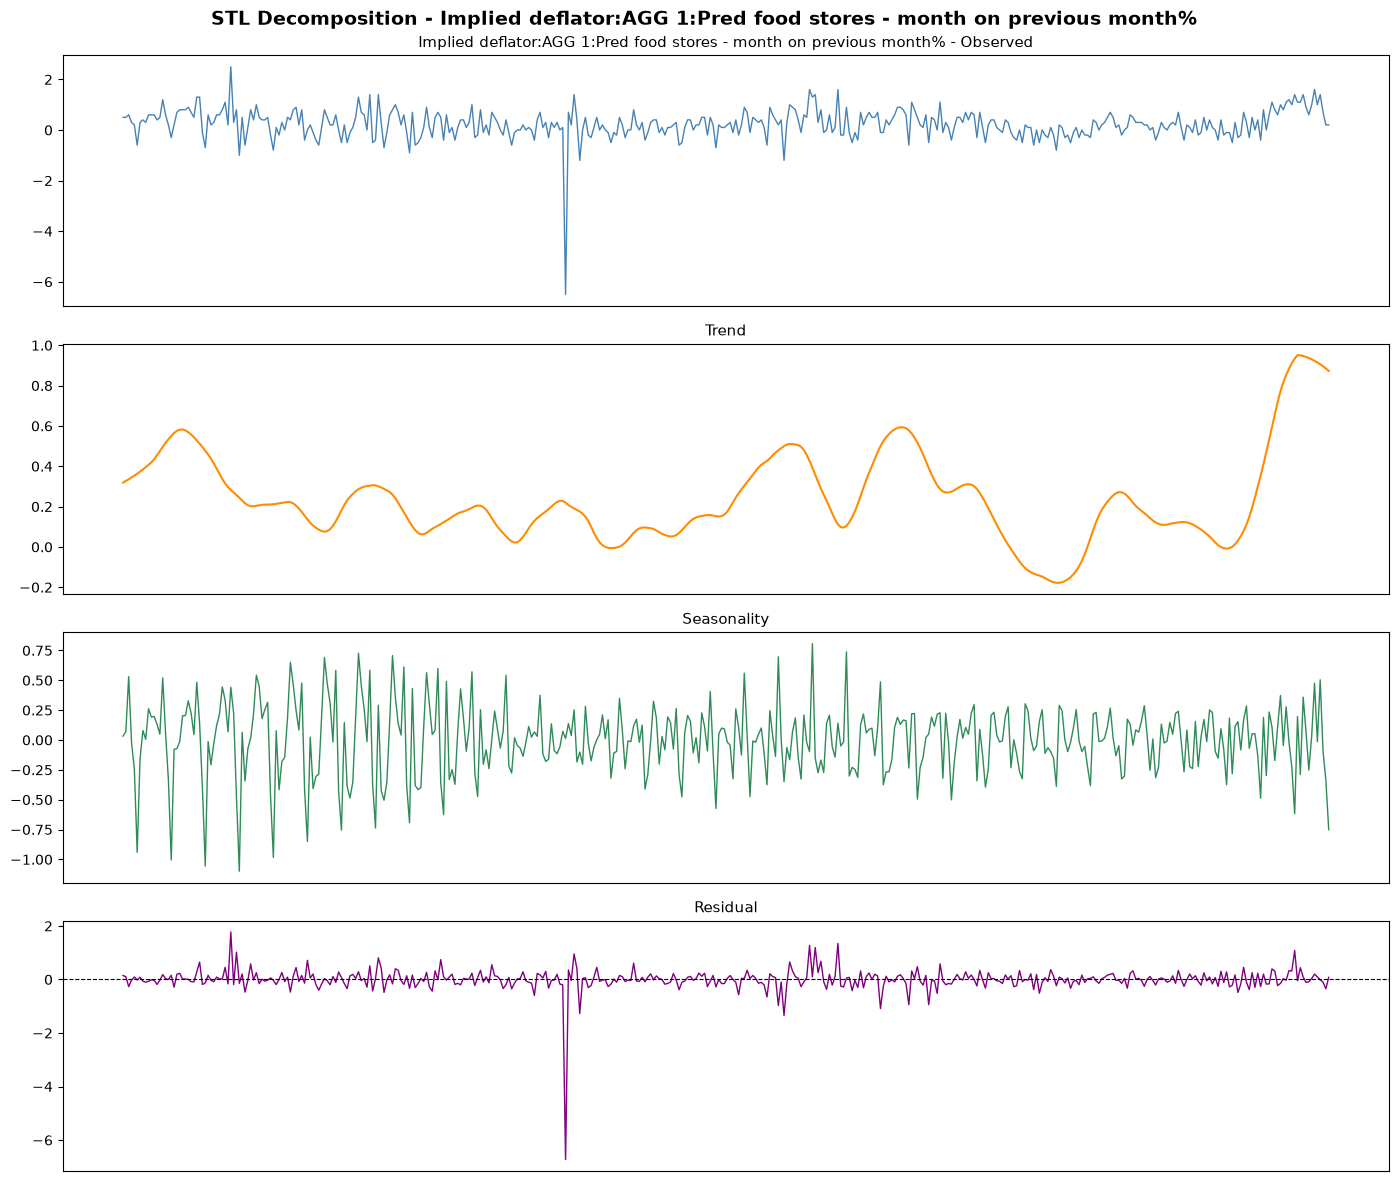

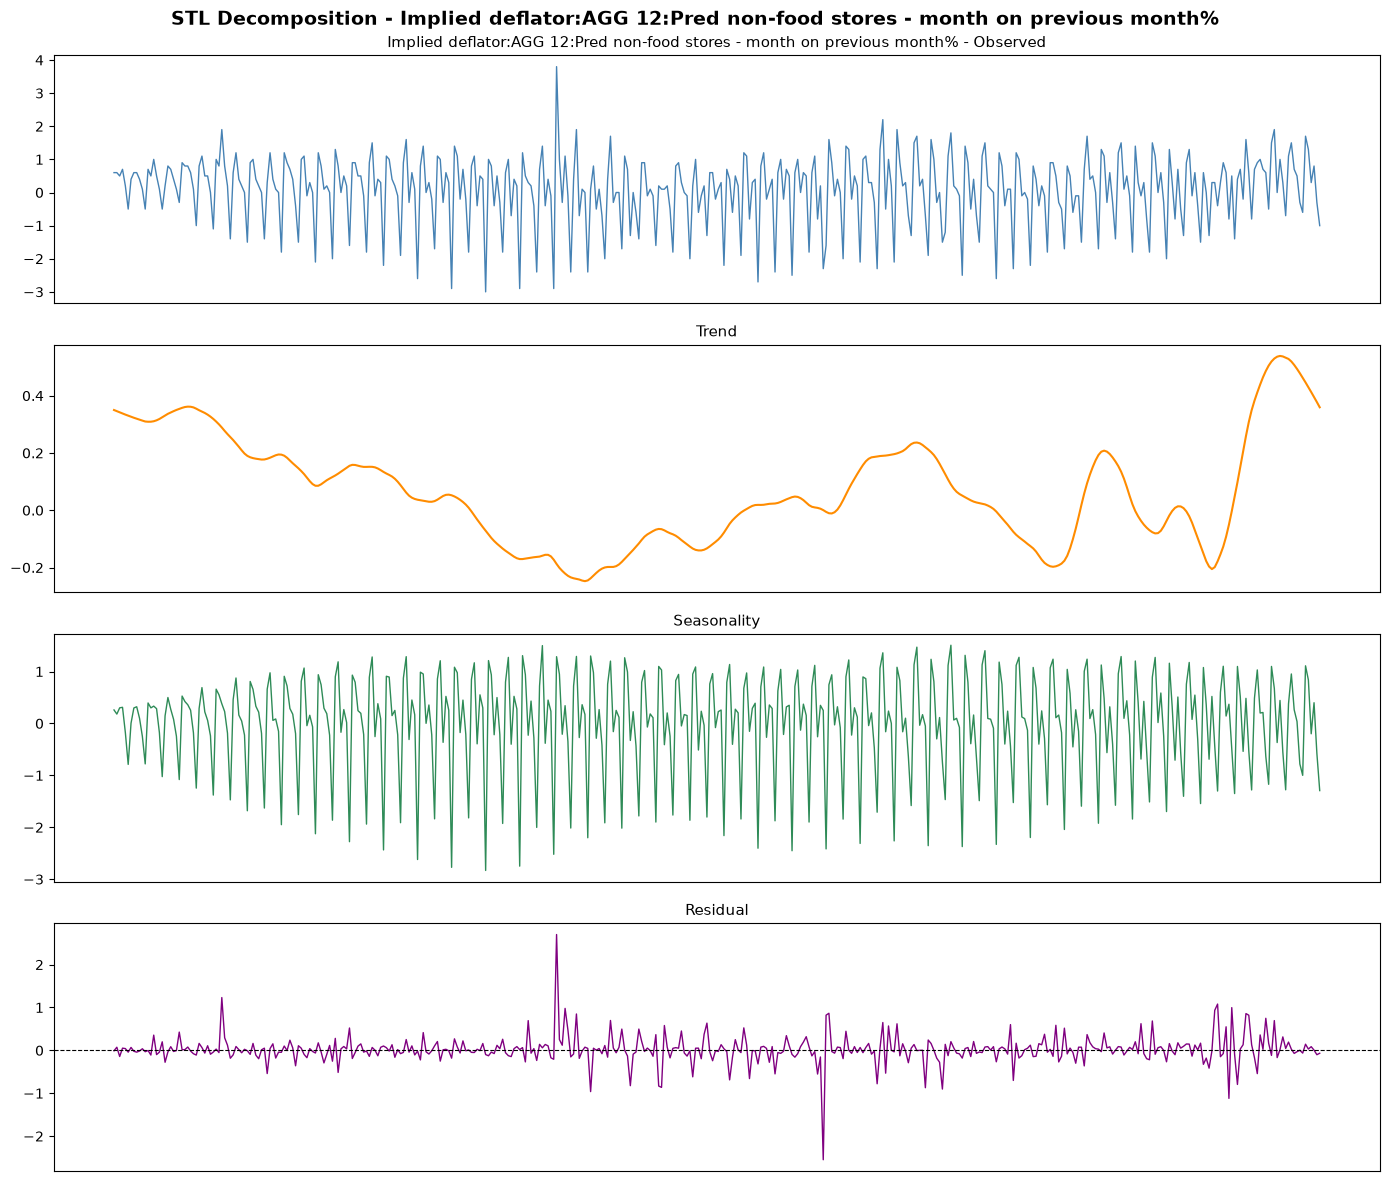

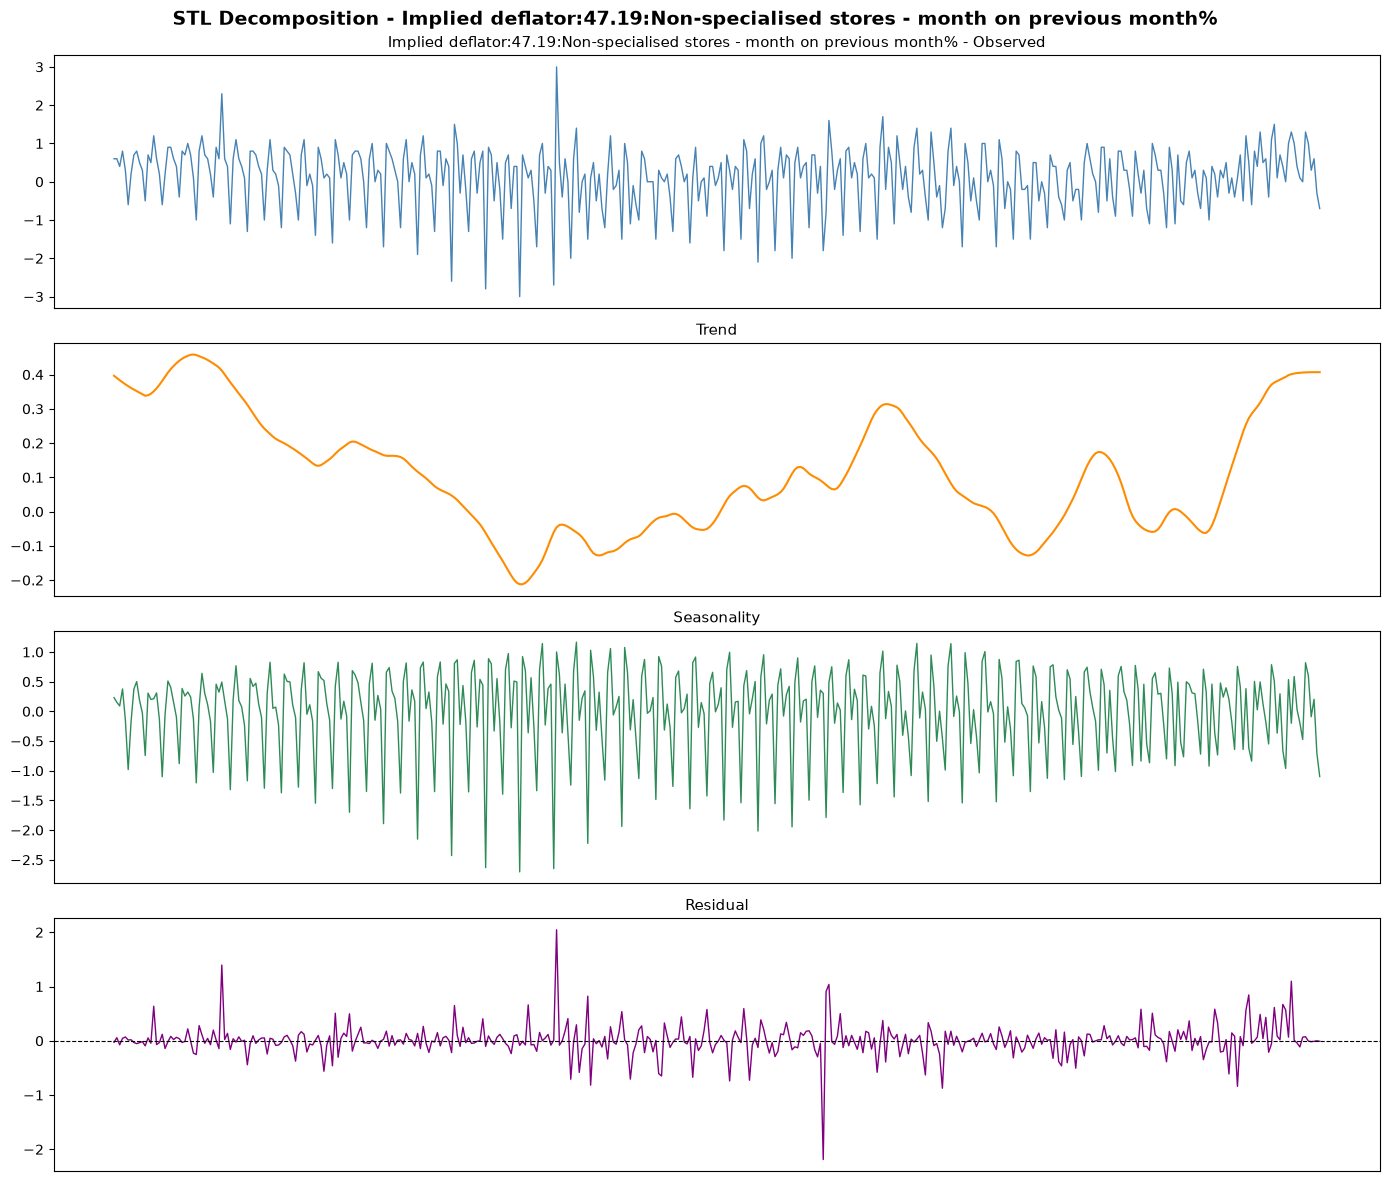

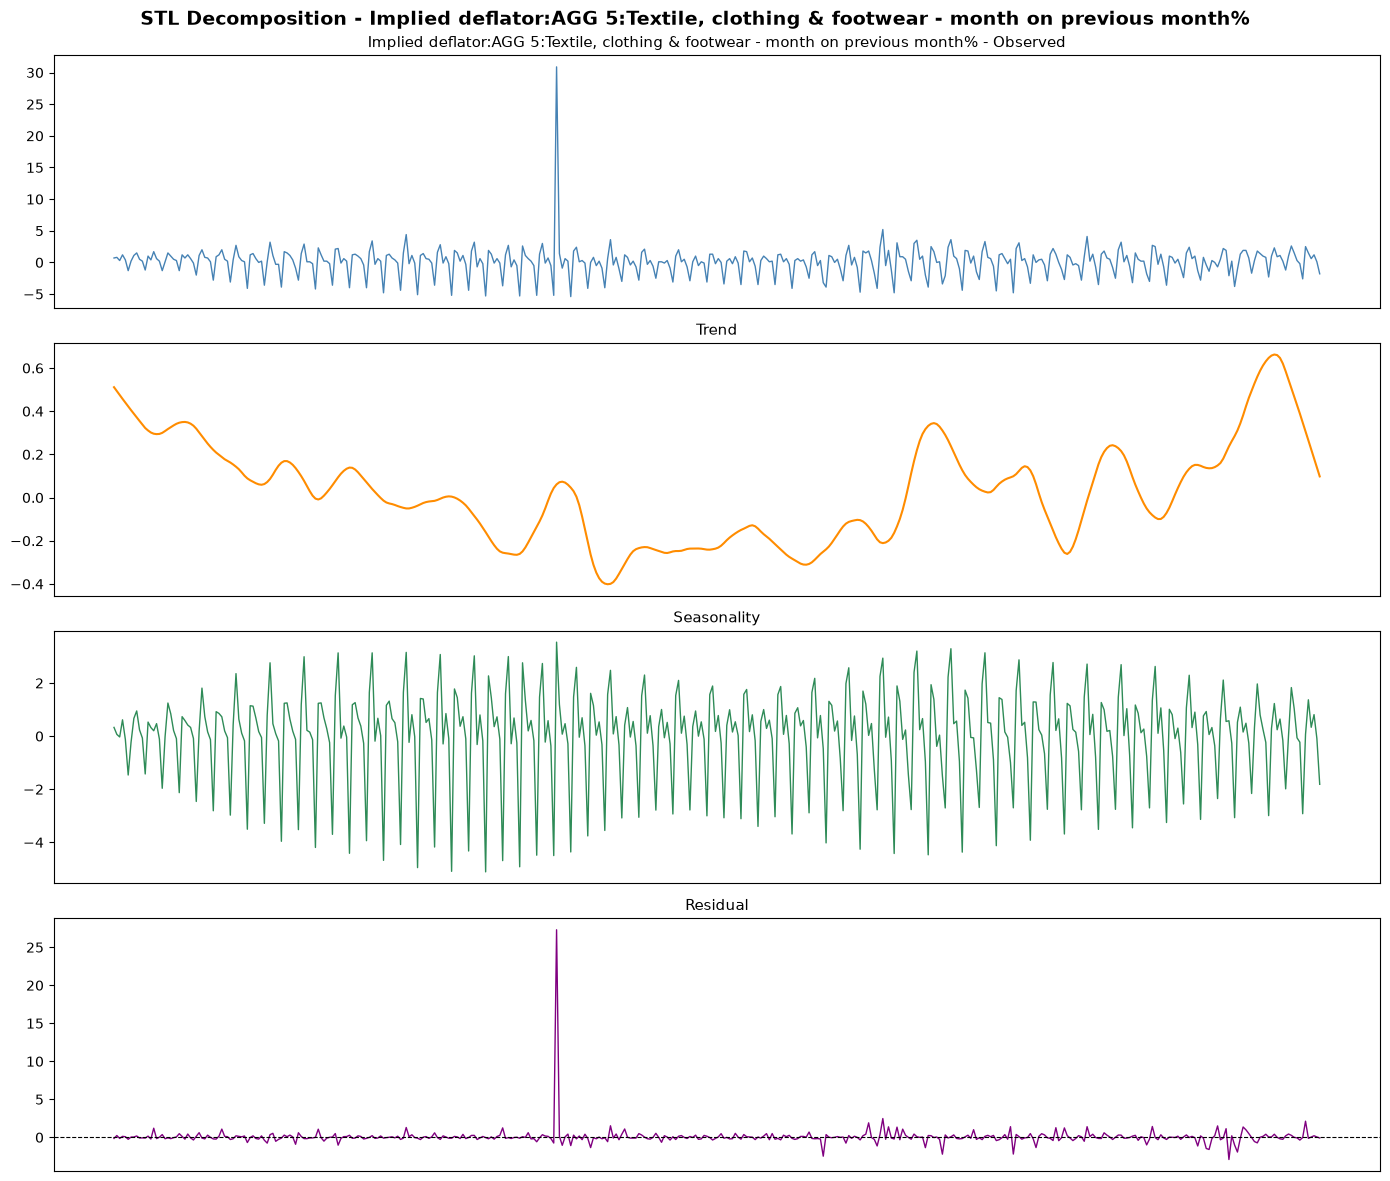

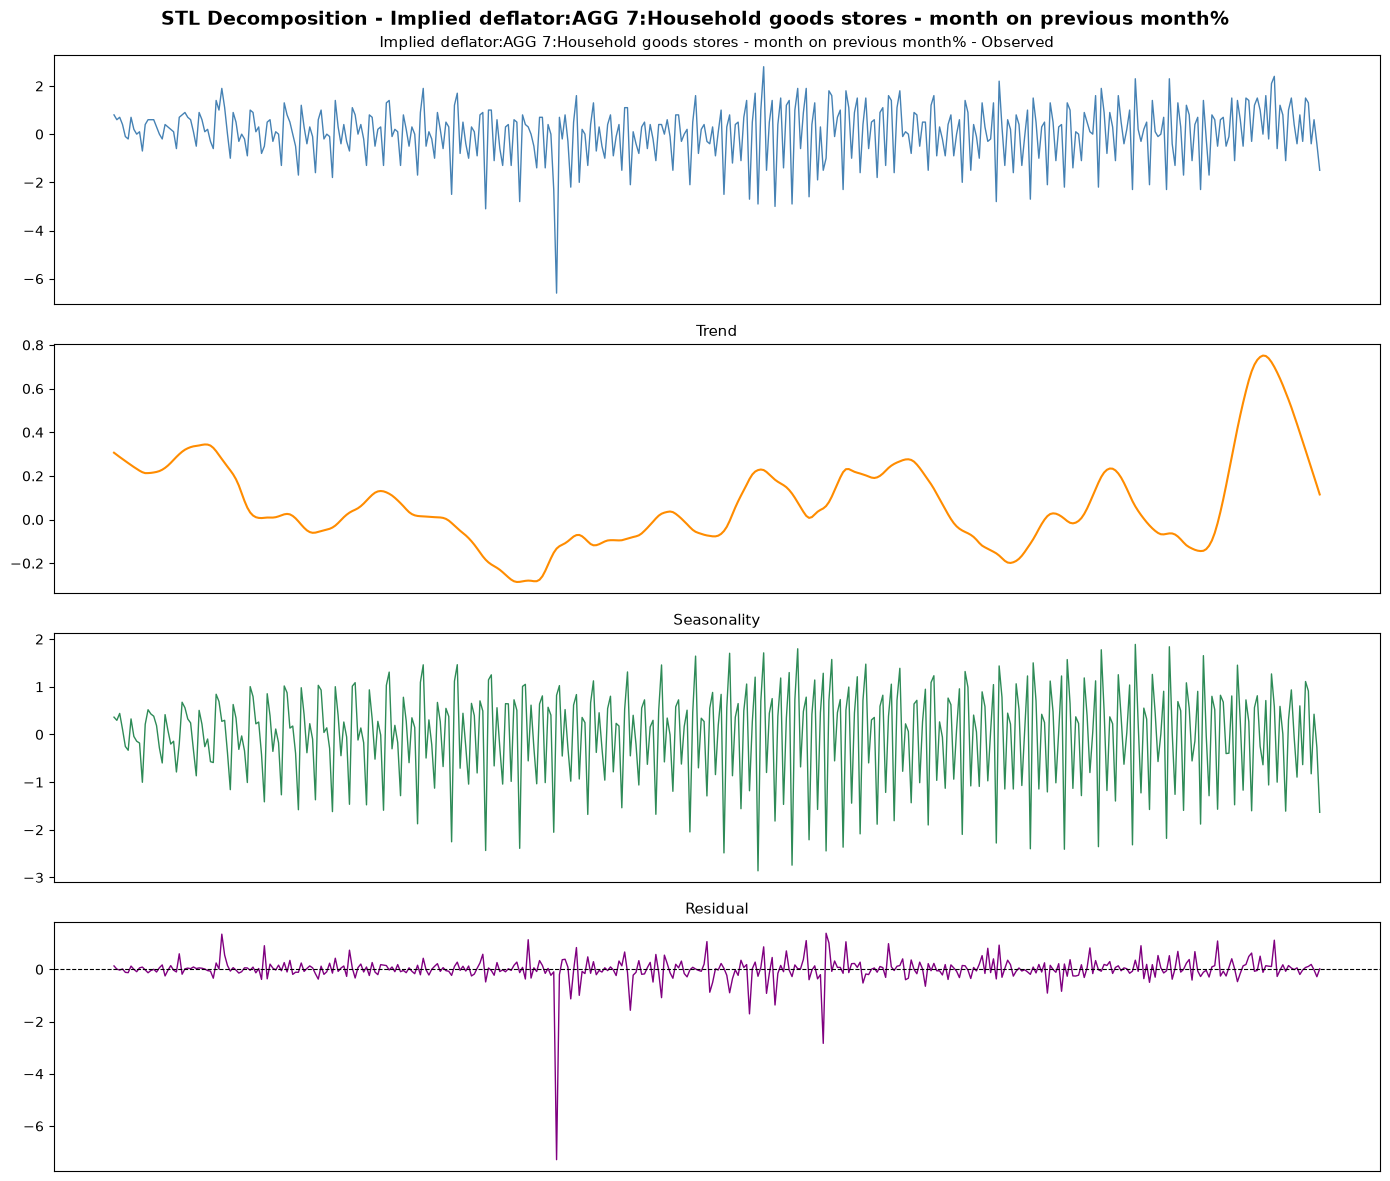

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Make sure index is datetime
data.index = pd.to_datetime(data.index)
data = data.sort_index()

# Choose the seasonal period
period = 12   # Example: hourly data with daily seasonality

# Store decomposition results
decomposed = {}

for col in value_cols:
    
    series = data[col].dropna()

    # STL decomposition
    stl = STL(
        series,
        period=period,
        robust=True
    )

    result = stl.fit()

    # Store components
    decomposed[col] = {
        "observed": series,
        "trend": result.trend,
        "seasonal": result.seasonal,
        "residual": result.resid
    }
import matplotlib.pyplot as plt

for col in value_cols[:5]:

    result = decomposed[col]

    fig, axes = plt.subplots(
        4, 1,
        figsize=(14, 12),
        sharex=True
    )

    # Original data
    axes[0].plot(
        result["observed"].index,
        result["observed"],
        color="steelblue",
        linewidth=1
    )
    axes[0].set_title(f"{col} - Observed", fontsize=11)

    # Trend
    axes[1].plot(
        result["trend"].index,
        result["trend"],
        color="darkorange",
        linewidth=1.5
    )
    axes[1].set_title("Trend", fontsize=11)

    # Seasonality
    axes[2].plot(
        result["seasonal"].index,
        result["seasonal"],
        color="seagreen",
        linewidth=1
    )
    axes[2].set_title("Seasonality", fontsize=11)

    # Residual
    axes[3].plot(
        result["residual"].index,
        result["residual"],
        color="purple",
        linewidth=1
    )
    axes[3].axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8
    )
    axes[3].set_title("Residual", fontsize=11)

    fig.suptitle(
        f"STL Decomposition - {col}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


In [154]:
import re

def get_base_name(col):
    col = str(col)
    col = re.sub(r'\bNSA\b', '', col)
    col = re.sub(r'\bSA\b', '', col)
    return ' '.join(col.split())

sa_base = {get_base_name(col): col for col in sa_cols}
nsa_base = {get_base_name(col): col for col in nsa_cols}

common = set(sa_base) & set(nsa_base)

print("SA columns:", len(sa_cols))
print("NSA columns:", len(nsa_cols))
print("Matching SA/NSA metrics:", len(common))

SA columns: 112
NSA columns: 90
Matching SA/NSA metrics: 29


In [155]:
for base in list(common)[:20]:
    print("SA :", sa_base[base])
    print("NSA:", nsa_base[base])
    print()

SA : RSI:Internet: Val SA:Non-store Retailing:All Business Index
NSA: RSI:Internet: Val NSA:Non-store Retailing:All Business Index

SA : RSI:Internet: Val SA:All Retailers ex fuel:All Business Index
NSA: RSI:Internet: Val NSA:All Retailers ex fuel:All Business Index

SA : RSI:All retail inc fuel:All Business:VOL SA:% change on same month a year ago
NSA: RSI:All retail inc fuel:All Business:VOL NSA:% change on same month a year ago

SA : RSI:Non-store retailing:All Business:VAL SA:Rolling 3m on same 3m a year ago %
NSA: RSI:Non-store retailing:All Business:VAL NSA:Rolling 3m on same 3m a year ago %

SA : RSI:Internet:All retail ex fuelAll Business:VAL SA:% change month a year ago
NSA: RSI:Internet:All retail ex fuelAll Business:VAL NSA:% change month a year ago

SA : RSI:Pred food stores:All Business:VOL SA:Rolling 3m on same 3m a year ago %
NSA: RSI:Pred food stores:All Business:VOL NSA:Rolling 3m on same 3m a year ago %

SA : RSI:Automotive fuel:All Business:VAL SA:% change on same mo

Implied deflator:AGG 1:Pred food stores - month on previous month%: 1 residual Z-score outliers
Implied deflator:AGG 12:Pred non-food stores - month on previous month%: 2 residual Z-score outliers
Implied deflator:47.19:Non-specialised stores - month on previous month%: 3 residual Z-score outliers
Implied deflator:AGG 5:Textile, clothing & footwear - month on previous month%: 1 residual Z-score outliers
Implied deflator:AGG 7:Household goods stores - month on previous month%: 2 residual Z-score outliers


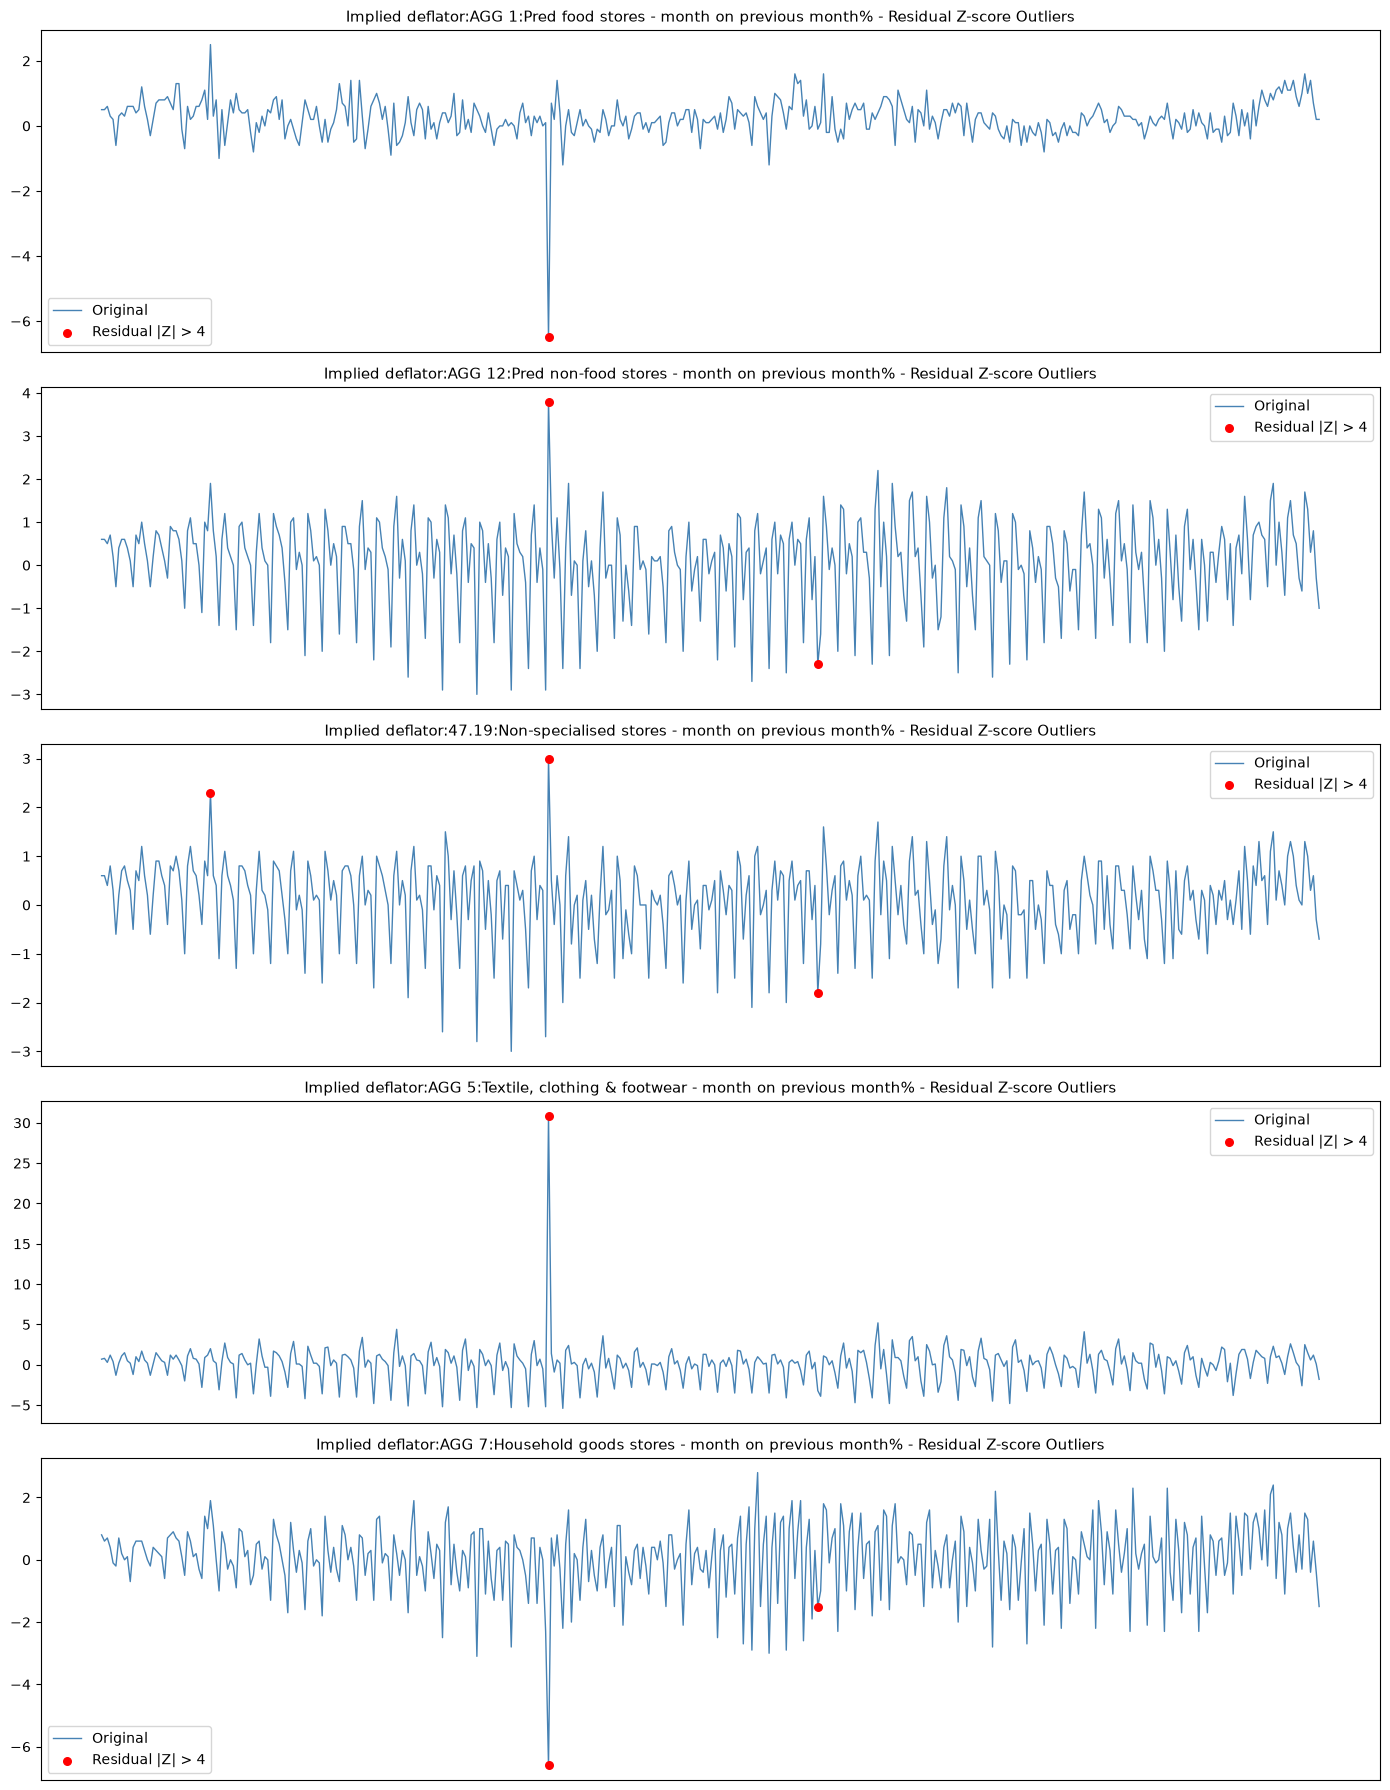

In [115]:
import matplotlib.pyplot as plt

# Z-score threshold
z_threshold = 4

# Plot first 5 variables
fig, axes = plt.subplots(
    5, 1,
    figsize=(14, 18),
    sharex=True
)

for ax, col in zip(axes, value_cols[:5]):

    # Get original series and STL residual
    observed = decomposed[col]["observed"]
    residual = decomposed[col]["residual"]

    # -----------------------------------------
    # Calculate Z-score on residual
    # -----------------------------------------
    z_scores = (
        residual - residual.mean()
    ) / residual.std()

    # Identify residual Z-score outliers
    outliers = z_scores.abs() > z_threshold

    # -----------------------------------------
    # Plot original time series
    # -----------------------------------------
    ax.plot(
        observed.index,
        observed,
        color="steelblue",
        linewidth=1,
        label="Original"
    )

    # -----------------------------------------
    # Highlight residual Z-score outliers
    # -----------------------------------------
    ax.scatter(
        observed.index[outliers],
        observed[outliers],
        color="red",
        s=30,
        label=f"Residual |Z| > {z_threshold}",
        zorder=3
    )

    # -----------------------------------------
    # Formatting
    # -----------------------------------------
    ax.set_title(
        f"{col} - Residual Z-score Outliers",
        fontsize=11
    )

    ax.legend()

    # Print number of outliers
    print(
        f"{col}: {outliers.sum()} "
        f"residual Z-score outliers"
    )

plt.tight_layout()
plt.show()


# 2. Data Cleaning (20)
### a. Handling Missing Values

In [100]:
gap_results = []

for freq, group in data.groupby('Frequency'):

    dates = (
        group['Date']
        .dropna()
        .drop_duplicates()
        .sort_values()
    )

    if freq == 'Annual':
        expected_months = 12
    elif freq == 'Quarterly':
        expected_months = 3
    elif freq == 'Monthly':
        expected_months = 1
    else:
        continue

    month_diff = (
        dates.dt.year.diff() * 12
        + dates.dt.month.diff()
    )

    gaps = month_diff[month_diff > expected_months]

    gap_results.append({
        'Frequency': freq,
        'Number of gaps': len(gaps),
        'Gaps': gaps.tolist()
    })

gap_results = pd.DataFrame(gap_results)

display(gap_results)

,Frequency,Number of gaps,Gaps
0,Annual,0,[]
1,Monthly,0,[]
2,Quarterly,0,[]


In [116]:
# Sort by date
data = data.sort_values('Date')

# Find first and last actual observation
first_date = data['Date'].min()
last_date = data['Date'].max()

# Keep only rows within the observed period
within_period = data[
    (data['Date'] >= first_date) &
    (data['Date'] <= last_date)
]

# Count NaNs in each column
print(within_period.isna().sum())

Title                                                                               0
Implied deflator:AGG 1:Pred food stores - month on previous month%                178
Implied deflator:AGG 12:Pred non-food stores - month on previous month%           178
Implied deflator:47.19:Non-specialised stores - month on previous month%          178
Implied deflator:AGG 5:Textile, clothing & footwear - month on previous month%    178
                                                                                 ... 
AGG 13: Implied Deflator Index: Other stores                                      177
AGG 14: Implied Deflator Index: Non store retailing                               177
47.30: Implied Deflator Index: Predominantly automotive fuel                      261
Date                                                                                0
Frequency                                                                           0
Length: 624, dtype: int64


In [119]:
for col in data.columns:
    if col in ['Title', 'Date', 'Frequency']:
        continue

    for freq, group in data.groupby('Frequency'):
        group = group.sort_values('Date')

        valid = group[group[col].notna()]

        if len(valid) == 0:
            continue

        first = valid['Date'].min()
        last = valid['Date'].max()

        missing_between = group[
            (group['Date'] >= first) &
            (group['Date'] <= last) &
            (group[col].isna())
        ]

        if len(missing_between) > 0:
            print(f"{col} | {freq} | {len(missing_between)} NaNs between observations")

This shows that the missing values from the first observation to the last observation is following an expected pattern. Yearly observations has a freq for every 12 months and every quarter has a frq of 3 months. This is expected and should not be imputed. 

In [136]:
cols = [
    col for col in data.columns
    if 'RSI:Internet:Household goods stores:All Bus' in col
]

print(*cols, sep='\n')

RSI:Internet:Household goods stores:All Bus:VAL NSA:%change month a year ago
RSI:Internet:Household goods stores:All Bus:VAL SA:%change month a year ago
RSI:Internet:Household goods stores:All Bus:VAL NSA:internet ave weekly sales £m


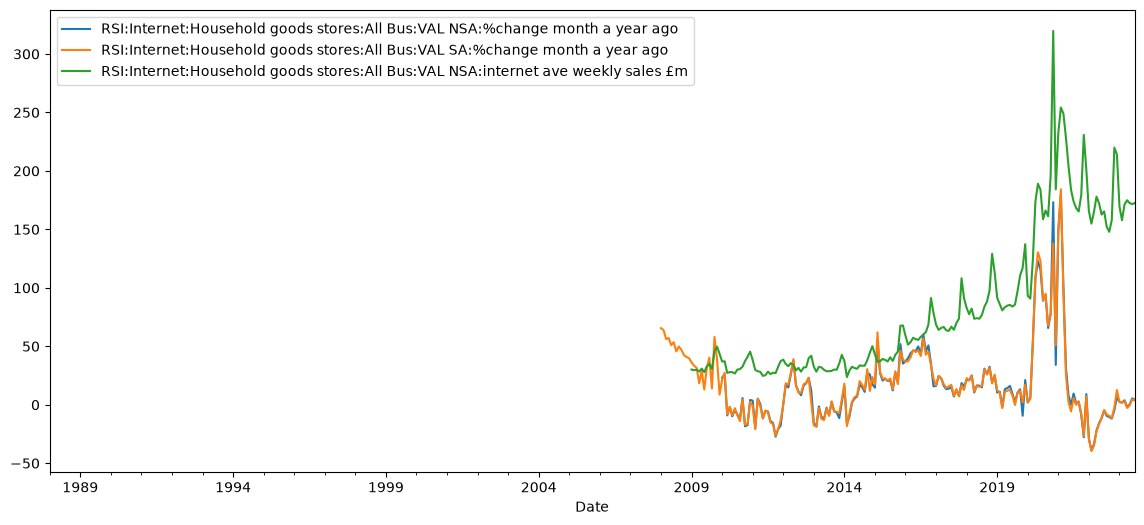

In [137]:
plot_data = data[data['Frequency'] == 'Monthly'][['Date'] + cols]

plot_data.plot(
    x='Date',
    y=cols,
    figsize=(14, 6)
)

plt.show()

In [141]:
ranges = []

for col in data.columns:
    if col in ['Title', 'Date', 'Frequency']:
        continue

    for freq, group in data.groupby('Frequency'):
        valid = group[group[col].notna()]

        if len(valid) > 0:
            first = valid['Date'].min()
            last = valid['Date'].max()

            ranges.append({
                'Variable': col,
                'Frequency': freq,
                'First': first,
                'Last': last,
                'Observations': len(valid),
                'Days': (last - first).days
            })

ranges = pd.DataFrame(ranges)

In [145]:
ranges[ranges["Variable"] == "RSI:Internet:Household goods stores:All Bus:VAL NSA:%change month a year ago"][[
    "Variable", "Frequency", "First", "Last", "Observations"
]]

,Variable,Frequency,First,Last,Observations
1246,RSI:Internet:Household goods stores:All Bus:VA...,Annual,2010-01-01,2022-01-01,13
1247,RSI:Internet:Household goods stores:All Bus:VA...,Monthly,2010-01-01,2023-07-01,163
1248,RSI:Internet:Household goods stores:All Bus:VA...,Quarterly,2010-01-01,2023-04-01,54


In [ ]:
row_missing = data.isna().sum(axis=1)

worst_row = row_missing.idxmax()

print(data.loc[worst_row, ['Date', 'Frequency']])
print("Missing:", row_missing.loc[worst_row])
print("Present:", data.loc[worst_row].notna().sum())

Date         1988-01-01 00:00:00
Frequency                 Annual
Name: 1970-01-01 00:00:00, dtype: object
Missing: 469
Present: 155


In [149]:
value_cols = data.columns.difference(['Title', 'Date', 'Frequency'])

for col in value_cols:
    valid = data.loc[data[col].notna(), 'Date']

    if len(valid) > 0:
        print(col, valid.min(), valid.max())

47.19: Implied Deflator Index: Non-specialised stores 1988-01-01 00:00:00 2023-07-01 00:00:00
47.30: Implied Deflator Index: Predominantly automotive fuel 1995-01-01 00:00:00 2023-07-01 00:00:00
AGG 12: Implied Deflator Index:Total Predominantly non-food stores 1988-01-01 00:00:00 2023-07-01 00:00:00
AGG 13: Implied Deflator Index: Other stores 1988-01-01 00:00:00 2023-07-01 00:00:00
AGG 14: Implied Deflator Index: Non store retailing 1988-01-01 00:00:00 2023-07-01 00:00:00
AGG 1: Implied Deflator Index: Predominantly food stores 1988-01-01 00:00:00 2023-07-01 00:00:00
AGG 21: Implied Deflator Index: All retailing including automotive fuel 1988-01-01 00:00:00 2023-07-01 00:00:00
AGG 21X: Implied Deflator Index: All retailing excluding automotive fuel 1988-01-01 00:00:00 2023-07-01 00:00:00
AGG 5: Implied Deflator Index: Textile, clothing and footwear stores 1988-01-01 00:00:00 2023-07-01 00:00:00
AGG 7: Implied Deflator Index: Household goods stores 1988-01-01 00:00:00 2023-07-01 00:00

In [151]:
col = 'RSI:Internet:Household goods stores:All Bus:VAL NSA:internet ave weekly sales £m'

for freq, group in data.groupby('Frequency'):
    values = group[col]
    
    print(freq)
    print("Observations:", values.notna().sum())
    print("NaNs:", values.isna().sum())

Annual
Observations: 0
NaNs: 35
Monthly
Observations: 175
NaNs: 252
Quarterly
Observations: 0
NaNs: 142


In [179]:
"""
Retail Sales Time Series - Outlier Detection & Handling (v2)
================================================================
Builds on the prior cleaning step (metadata removal, Title -> Date/Frequency,
numeric conversion). Revision note: v1 only deseasonalized the 46 NSA
columns that had a matched SA counterpart, using the NSA/SA ratio residual.
Checking those 46 columns showed ~86% of their naively-flagged outliers
were just recurring seasonal peaks (e.g. December), not real anomalies.
Rather than only fixing the columns that happen to have an SA partner,
v2 applies the same idea to EVERY monthly/quarterly column using each
column's OWN history - no SA counterpart required.

  1. Classify each value column as 'percent' (already a change/ratio,
     roughly stationary) or 'level' (an index/£ series that trends).
  2. Build the same "test series" as before: raw values for percent
     columns, period-on-period % change for level columns.
  3. Deseasonalize the test series using a seasonal-naive decomposition:
     for Monthly data, subtract that column's own mean value for each
     calendar month (Jan mean, Feb mean, ...); for Quarterly, subtract
     the column's own mean for each quarter-of-year. This needs at least
     3 observations of that month/quarter to compute a mean, and uses
     only that column's own valid window - never a pair.
     Columns whose name already signals a year-on-year comparison
     ("year ago", "year earlier", "year on year", "year to date") are
     left alone, since comparing the same calendar period across years
     already cancels normal seasonality.
  4. Run IQR (1.5x fences) AND a modified/MAD-based Z-score
     (|z| > 3.5) on the deseasonalized residual; a point must be
     flagged by BOTH to be "confirmed" - this two-method agreement
     limits false positives from either test alone, and MAD (unlike
     mean/std) is not itself distorted by the extreme points it's
     trying to detect.
  5. Handle confirmed outliers by REPLACING them with a linear
     interpolation between their nearest valid, non-outlier neighbours
     in the same column/frequency block - bounding their influence
     without deleting rows or breaking the 622-column panel alignment.

The 46 matched NSA/SA Index pairs are still used, but only as a
validation check (see `validate_against_sa_pairs()` below) confirming
that the seasonal-naive residual lines up with the ratio-based residual
computed from the real SA series.

Outputs
-------
/mnt/user-data/outputs/drsi_outliers_handled.csv  - full cleaned dataset
/mnt/user-data/outputs/outlier_log.csv            - every point changed
"""
import re
import numpy as np
import pandas as pd

RAW_PATH = "../data/retail-sales-time-series/drsi.csv"
MIN_OBS = 8
Z_THRESH = 3.5
IQR_MULT = 1.5

# ---------------------------------------------------------------- #
# 1. Load + reproduce the prior cleaning step
# ---------------------------------------------------------------- #
df = df_raw.copy()
data = df.iloc[6:].reset_index(drop=True).rename(columns={df.columns[0]: "Title"})


def parse_freq(title):
    t = str(title).strip()
    if re.fullmatch(r"\d{4}", t):
        return "Annual"
    if re.fullmatch(r"\d{4} Q[1-4]", t):
        return "Quarterly"
    if re.fullmatch(r"\d{4} [A-Z]{3}", t):
        return "Monthly"
    return "Unknown"


def parse_date(row):
    t, f = row["Title"].strip(), row["Frequency"]
    if f == "Annual":
        return pd.Timestamp(year=int(t), month=1, day=1)
    if f == "Quarterly":
        y, q = t.split(" ")
        return pd.Timestamp(year=int(y), month=(int(q[1]) - 1) * 3 + 1, day=1)
    if f == "Monthly":
        return pd.to_datetime(t, format="%Y %b")
    return pd.NaT


data["Frequency"] = data["Title"].apply(parse_freq)
data["Date"] = data.apply(parse_date, axis=1)
value_cols = [c for c in data.columns if c not in ("Title", "Frequency", "Date")]
for c in value_cols:
    data[c] = pd.to_numeric(data[c], errors="coerce")
data = data.sort_values("Date").reset_index(drop=True)

# ---------------------------------------------------------------- #
# 2. Column typing
# ---------------------------------------------------------------- #


def col_type(c):
    cl = c.lower()
    if "index" in cl:
        return "level"
    if "%" in c or "percent" in cl or "proportion" in cl:
        return "percent"
    return "level"


types = {c: col_type(c) for c in value_cols}


def already_deseasonalized(c):
    cl = c.lower()
    return any(k in cl for k in ["year ago", "year earlier", "year on year", "yoy", "year to date"])


def mad_zscore(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return np.zeros_like(x) if mad == 0 else 0.6745 * (x - med) / mad


period_map = {"Monthly": data["Date"].dt.month, "Quarterly": data["Date"].dt.quarter}

# ---------------------------------------------------------------- #
# 3-4. Detect: deseasonalize (own-history seasonal-naive) + IQR/MAD test
# ---------------------------------------------------------------- #
records = []
for c in value_cols:
    for freq, sub in data.groupby("Frequency"):
        s = sub[c]
        valid = s.notna()
        if valid.sum() < MIN_OBS:
            continue
        idx, raw = sub.index[valid], s[valid].values
        test_vals = raw.copy() if types[c] == "percent" else pd.Series(raw).pct_change().values

        if freq in period_map and not already_deseasonalized(c):
            period = period_map[freq].loc[idx].values
            tmp = pd.Series(test_vals, index=idx)
            seasonal_avg = tmp.groupby(period).transform(
                lambda g: g.mean() if g.notna().sum() >= 3 else np.nan
            )
            test_vals = (tmp - seasonal_avg).values

        finite = np.isfinite(test_vals)
        if finite.sum() < MIN_OBS:
            continue
        tv, test_idx = test_vals[finite], idx[finite]
        q1, q3 = np.percentile(tv, [25, 75])
        iqr = q3 - q1
        iqr_flag = (tv < q1 - IQR_MULT * iqr) | (tv > q3 + IQR_MULT * iqr)
        z_flag = np.abs(mad_zscore(tv)) > Z_THRESH
        confirmed = iqr_flag & z_flag
        for i, date, flagged in zip(test_idx, sub.loc[test_idx, "Date"], confirmed):
            if flagged:
                records.append({"column": c, "type": types[c], "frequency": freq,
                                 "row_index": i, "date": date})
outlier_log = pd.DataFrame(records)

# ---------------------------------------------------------------- #
# Validation: does this line up with the ratio-based SA/NSA residual
# for the 46 matched Index pairs? (sanity check only, not a gate)
# ---------------------------------------------------------------- #


def norm_key(c):
    s = c.upper()
    s = re.sub(r"\(NSA\)|\(SA\)|\bNSA\b|\bSA\b", "", s)
    return re.sub(r"[^A-Z0-9]+", "", s)


is_nsa = lambda c: bool(re.search(r"\(NSA\)|\bNSA\b", c.upper()))
is_sa = lambda c: bool(re.search(r"\(SA\)|\bSA\b", c.upper())) and not is_nsa(c)
nsa_map, sa_map = {}, {}
for c in value_cols:
    if is_nsa(c):
        nsa_map.setdefault(norm_key(c), []).append(c)
    elif is_sa(c):
        sa_map.setdefault(norm_key(c), []).append(c)
pairs = [(n, s) for k, ns in nsa_map.items() if k in sa_map for n in ns for s in sa_map[k]]
level_pairs = [(n, s) for n, s in pairs if types[n] == "level" and types[s] == "level"]


def validate_against_sa_pairs():
    monthly = data[data["Frequency"] == "Monthly"].copy()
    monthly["month"] = monthly["Date"].dt.month
    agree, disagree = 0, 0
    for nsa_c, sa_c in level_pairs:
        sub = monthly[["Date", "month", nsa_c, sa_c]].dropna()
        if len(sub) < 24:
            continue
        ratio = sub[nsa_c] / sub[sa_c]
        seasonal_avg = ratio.groupby(sub["month"]).transform("mean")
        irregular = ratio - seasonal_avg
        q1, q3 = np.percentile(irregular, [25, 75])
        iqr = q3 - q1
        resid_flag = ((irregular < q1 - IQR_MULT * iqr) | (irregular > q3 + IQR_MULT * iqr)) & (
            np.abs(mad_zscore(irregular.values)) > Z_THRESH
        )
        sa_pair_dates = set(sub.loc[resid_flag, "Date"])
        our_dates = set(outlier_log.loc[(outlier_log["column"] == nsa_c) & (outlier_log["frequency"] == "Monthly"), "date"])
        agree += len(sa_pair_dates & our_dates)
        disagree += len(sa_pair_dates ^ our_dates)
    return agree, disagree


agree, disagree = validate_against_sa_pairs()
print(f"Validation vs. real SA-pair residual (46 Index pairs): {agree} dates agree, {disagree} disagree")

# ---------------------------------------------------------------- #
# 5. Handle: replace confirmed outliers with local linear interpolation
# ---------------------------------------------------------------- #
cleaned = data.copy()
for col, grp in outlier_log.groupby("column"):
    for freq, g in grp.groupby("frequency"):
        block_idx = data.index[data["Frequency"] == freq]
        s = cleaned.loc[block_idx, col].copy()
        s.loc[g["row_index"].values] = np.nan
        cleaned.loc[block_idx, col] = s.interpolate(method="linear", limit_direction="both")

# ---------------------------------------------------------------- #
# 6. Export
# ---------------------------------------------------------------- #
cleaned[["Title", "Frequency", "Date"] + value_cols].to_csv(
    "drsi_outliers_handled.csv", index=False
)
outlier_log[["column", "type", "frequency", "date"]].sort_values(["column", "date"]).to_csv(
    "outlier_log.csv", index=False
)

total_valid = sum(data[c].notna().sum() for c in value_cols)
print(f"Confirmed outliers (IQR & |mod-z|>{Z_THRESH}, deseasonalized): {len(outlier_log)}")
print(f"Share of all valid observations changed: {100*len(outlier_log)/total_valid:.2f}%")
print(f"Columns touched: {outlier_log['column'].nunique()} / {len(value_cols)}")

Validation vs. real SA-pair residual (46 Index pairs): 151 dates agree, 843 disagree
Confirmed outliers (IQR & |mod-z|>3.5, deseasonalized): 10951
Share of all valid observations changed: 3.64%
Columns touched: 610 / 621
